In [ ]:
from model_fitting import fit_compare_to_threshold_model
from nwb_utils import NWBUtils

nwb_file_name='/root/capsule/scratch/general_behavior/698694/698694_2024-04-17_12-21-55.nwb'
nwb_data=NWBUtils.read_behavior_nwb(nwb_full_path=nwb_file_name)


In [ ]:
fitted_data=fit_compare_to_threshold_model(nwb_data,
                                        reset_on_switch=True,
                                        include_bias=True,
                                        save_results=True,
                                        save_folder='/root/capsule/scratch/CTT_reset_bias'
                                        )

In [ ]:
from __future__ import annotations

import os
import gc
import traceback
from pathlib import Path
import concurrent.futures as cf
from typing import Dict, Any, List

from nwb_utils import NWBUtils
from model_fitting import fit_compare_to_threshold_model


NWB_ROOT = Path("/root/capsule/scratch/general_behavior")
OUT_ROOT = Path("/root/capsule/scratch/CTT_grid_json_only_by_animal")

RESET_OPTIONS = [True, False]
BIAS_OPTIONS = [True, False]


def combo_outdir(out_root: Path, animal_id: str, reset_on_switch: bool, include_bias: bool) -> Path:
    return out_root / str(animal_id) / f"reset_on_switch_{reset_on_switch}" / f"include_bias_{include_bias}"


def find_all_nwbs_two_level(root: Path) -> List[Path]:
    nwb_files: List[Path] = []
    for animal_dir in sorted(p for p in root.iterdir() if p.is_dir()):
        nwb_files.extend(sorted(animal_dir.glob("*.nwb")))
    return nwb_files


def extract_animal_id(nwb_path: Path) -> str:
    return nwb_path.parent.name


def run_one_file(nwb_path: Path) -> Dict[str, Any]:
    animal_id = extract_animal_id(nwb_path)

    status: Dict[str, Any] = {
        "file": str(nwb_path),
        "animal_id": animal_id,
        "ok": True,
        "errors": [],
        "results": [],  # keep only small summaries
    }

    nwb_data = None
    try:
        nwb_data = NWBUtils.read_behavior_nwb(nwb_full_path=str(nwb_path))
    except Exception as e:
        status["ok"] = False
        status["errors"].append(
            {"stage": "read_nwb", "error": repr(e), "traceback": traceback.format_exc()}
        )
        return status

    try:
        for reset_on_switch in RESET_OPTIONS:
            for include_bias in BIAS_OPTIONS:
                out_dir = combo_outdir(OUT_ROOT, animal_id, reset_on_switch, include_bias)
                out_dir.mkdir(parents=True, exist_ok=True)

                model_name = f"CTT_reset{int(reset_on_switch)}_bias{int(include_bias)}"

                try:
                    fit_out = fit_compare_to_threshold_model(
                        nwb_data,
                        model_name=model_name,
                        reset_on_switch=reset_on_switch,
                        include_bias=include_bias,
                        save_results=True,
                        save_folder=out_dir,
                    )

                    if fit_out is None:
                        status["ok"] = False
                        status["errors"].append(
                            {
                                "stage": "fit",
                                "reset_on_switch": reset_on_switch,
                                "include_bias": include_bias,
                                "error": "fit returned None",
                            }
                        )
                    else:
                        status["results"].append(
                            {
                                "reset_on_switch": reset_on_switch,
                                "include_bias": include_bias,
                                "session_id": fit_out.get("session_id", "unknown"),
                                "auto_train_stage": fit_out.get("auto_train_stage", "unknown"),
                                "aic": fit_out.get("aic", None),
                                "bic": fit_out.get("bic", None),
                                "neg_log_likelihood": fit_out.get("neg_log_likelihood", None),
                            }
                        )

                    # Drop fit output immediately
                    del fit_out

                except Exception as e:
                    status["ok"] = False
                    status["errors"].append(
                        {
                            "stage": "fit_exception",
                            "reset_on_switch": reset_on_switch,
                            "include_bias": include_bias,
                            "error": repr(e),
                            "traceback": traceback.format_exc(),
                        }
                    )

        return status

    finally:
        # Ensure we release references and run GC.
        # This helps, but true release depends on NWB/HDF5 closing behavior.
        if nwb_data is not None:
            del nwb_data
        gc.collect()


OUT_ROOT.mkdir(parents=True, exist_ok=True)

nwb_files = find_all_nwbs_two_level(NWB_ROOT)
print(f"Found {len(nwb_files)} NWB files under: {NWB_ROOT}")
print(f"Saving JSON results under: {OUT_ROOT}")

max_workers = min(6, len(nwb_files), os.cpu_count() or 1)
print(f"Running with {max_workers} threads")

n_ok = 0
n_fail = 0

with cf.ThreadPoolExecutor(max_workers=max_workers) as ex:
    futures = {ex.submit(run_one_file, p): str(p) for p in nwb_files}

    for fut in cf.as_completed(futures):
        fpath = futures[fut]
        try:
            res = fut.result()
        except Exception as e:
            n_fail += 1
            print(f"[CRASH] {fpath} -> {repr(e)}")
            continue

        if res.get("ok", False):
            n_ok += 1
            print(f"[OK]   {res['animal_id']}  {fpath}")
        else:
            n_fail += 1
            print(f"[FAIL] {res['animal_id']}  {fpath}")
            for err in res.get("errors", [])[:2]:
                print("   ", err.get("stage", "unknown"), err.get("error", ""))
            if len(res.get("errors", [])) > 2:
                print("    ...")

print(f"Done. OK={n_ok}, FAIL={n_fail}")


In [2]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Optional, Union

import pandas as pd


def load_ctt_results_jsons_to_dataframe(
    results_root: Union[str, Path],
    *,
    recursive: bool = True,
    keep_latents: bool = False,
) -> pd.DataFrame:
    """
    Load all compare-to-threshold JSON result files under a results folder and
    concatenate them into a single pandas DataFrame.

    This is designed for the folder structure produced by your runner:
        CTT_grid_json_only_by_animal/
            <animal_id>/
                reset_on_switch_{True|False}/
                    include_bias_{True|False}/
                        <session_id>__<model_name>_fit_results.json

    Parameters
    ----------
    results_root
        Path to the root folder (e.g. /root/capsule/scratch/CTT_grid_json_only_by_animal).
    recursive
        If True, searches recursively for all *.json files under results_root.
        If False, only searches one level below results_root (not recommended here).
    keep_latents
        If True, keep the fitted_latent_variables field (which can be large) as
        a column containing dicts.
        If False, drop fitted_latent_variables to keep the DataFrame light-weight.

    Returns
    -------
    pd.DataFrame
        One row per JSON file. Nested dicts are flattened into columns using
        dotted keys, e.g.:
            fitted_params.alpha
            metadata.reset_on_switch

        If keep_latents=True, fitted_latent_variables is kept as a dict column
        (not flattened by default, since it can be huge).
    """

    root = Path(results_root)

    if not root.exists():
        raise FileNotFoundError(f"results_root does not exist: {root}")

    if recursive:
        json_files = sorted(root.rglob("*.json"))
    else:
        json_files = sorted(root.glob("*.json"))

    records: List[Dict[str, Any]] = []

    for jf in json_files:
        try:
            with open(jf, "r") as f:
                data = json.load(f)

            # Attach path-derived metadata that is useful for grouping
            # Expected layout: root / animal_id / reset_on_switch_X / include_bias_Y / file.json
            rel_parts = jf.relative_to(root).parts
            animal_id = rel_parts[0] if len(rel_parts) >= 1 else None

            reset_on_switch = None
            include_bias = None
            if len(rel_parts) >= 3:
                # e.g. "reset_on_switch_True"
                if rel_parts[1].startswith("reset_on_switch_"):
                    reset_on_switch = rel_parts[1].split("reset_on_switch_", 1)[1]
                    if reset_on_switch in ("True", "False"):
                        reset_on_switch = (reset_on_switch == "True")

                # e.g. "include_bias_False"
                if rel_parts[2].startswith("include_bias_"):
                    include_bias = rel_parts[2].split("include_bias_", 1)[1]
                    if include_bias in ("True", "False"):
                        include_bias = (include_bias == "True")

            data["_json_path"] = str(jf)
            data["_animal_id_from_path"] = animal_id
            data["_reset_on_switch_from_path"] = reset_on_switch
            data["_include_bias_from_path"] = include_bias

            # Optionally drop latents to avoid huge DF
            if not keep_latents and "fitted_latent_variables" in data:
                data.pop("fitted_latent_variables", None)

            records.append(data)

        except Exception as e:
            # Keep a minimal record for debugging failed loads
            records.append(
                {
                    "_json_path": str(jf),
                    "_load_error": repr(e),
                }
            )

    # Flatten nested dicts (except fitted_latent_variables if kept)
    df = pd.json_normalize(records, sep=".")

    # Optional: make common columns more convenient (if they exist)
    # If the JSON already contains these, the path-derived ones can be used as backup.
    if "animal_id" not in df.columns and "_animal_id_from_path" in df.columns:
        df["animal_id"] = df["_animal_id_from_path"]

    # If you want a single authoritative reset/include columns, prefer JSON metadata if present
    if "metadata.reset_on_switch" in df.columns and "_reset_on_switch_from_path" in df.columns:
        df["reset_on_switch"] = df["metadata.reset_on_switch"].where(
            df["metadata.reset_on_switch"].notna(), df["_reset_on_switch_from_path"]
        )
    elif "_reset_on_switch_from_path" in df.columns:
        df["reset_on_switch"] = df["_reset_on_switch_from_path"]

    if "metadata.include_bias" in df.columns and "_include_bias_from_path" in df.columns:
        df["include_bias"] = df["metadata.include_bias"].where(
            df["metadata.include_bias"].notna(), df["_include_bias_from_path"]
        )
    elif "_include_bias_from_path" in df.columns:
        df["include_bias"] = df["_include_bias_from_path"]

    return df


# Example usage:
# df = load_ctt_results_jsons_to_dataframe(
#     "/root/capsule/scratch/CTT_grid_json_only_by_animal",
#     keep_latents=False,
# )
# df.head()


In [ ]:

df = load_ctt_results_jsons_to_dataframe(
    "/root/capsule/scratch/CTT_grid_json_only_by_animal_fix_value_reset_0.2",
    keep_latents=False,
)
df.head()

In [3]:
from __future__ import annotations

from typing import Sequence, Optional, Dict, Any, List, Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_ctt_metric_distributions_by_condition(
    df: pd.DataFrame,
    *,
    metrics: Optional[Sequence[str]] = None,
    condition_cols: Sequence[str] = ("reset_on_switch", "include_bias"),
    auto_train_stages: Optional[Union[Sequence[Any], Any]] = None,
    dropna: bool = True,
    bins: int = 50,
    max_cols: int = 3,
) -> Dict[str, Any]:
    """
    Plot distribution (histogram) of key fit metrics/parameters for each
    (reset_on_switch, include_bias) condition, optionally filtering by
    auto_train_stage.

    Parameters
    ----------
    df
        DataFrame produced by your JSON loader.
    metrics
        Columns to plot.
    condition_cols
        Two columns defining the condition grid.
    auto_train_stages
        None → use all sessions
        single value or list → only include those stages
    dropna
        Drop NaNs per metric before plotting.
    bins
        Histogram bins.
    max_cols
        Maximum subplot columns.

    Returns
    -------
    dict mapping metric -> figure info
    """

    if metrics is None:
        metrics = [
            "log_likelihood",
            "aic",
            "bic",
            "fitted_params.alpha",
            "fitted_params.threshold",
            "fitted_params.beta",
            "fitted_params.bias",
        ]

    # -----------------------------
    # Filter by auto_train_stage
    # -----------------------------
    df_plot = df.copy()

    if auto_train_stages is not None:
        if "auto_train_stage" not in df_plot.columns:
            raise KeyError("Column 'auto_train_stage' not found in DataFrame.")

        if not isinstance(auto_train_stages, (list, tuple, set)):
            auto_train_stages = [auto_train_stages]

        df_plot = df_plot[df_plot["auto_train_stage"].isin(auto_train_stages)]

        print(
            f"Filtering auto_train_stage in {list(auto_train_stages)} "
            f"-> {len(df_plot)} rows remaining"
        )

    # -----------------------------
    # Validate condition columns
    # -----------------------------
    for c in condition_cols:
        if c not in df_plot.columns:
            raise KeyError(f"Missing condition column '{c}'")

    # Ensure consistent ordering of groups
    def _sort_key(v):
        if isinstance(v, bool):
            return int(v)
        if pd.isna(v):
            return 2
        return str(v)

    group_keys = sorted(
        df_plot[list(condition_cols)].drop_duplicates().itertuples(index=False, name=None),
        key=lambda t: tuple(_sort_key(x) for x in t),
    )

    out: Dict[str, Any] = {}

    stage_str = (
        "All stages"
        if auto_train_stages is None
        else f"Stages={list(auto_train_stages)}"
    )

    for metric in metrics:
        if metric not in df_plot.columns:
            continue

        n_groups = len(group_keys)
        ncols = min(max_cols, n_groups) if n_groups > 0 else 1
        nrows = int(np.ceil(n_groups / ncols)) if n_groups > 0 else 1

        fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                                 figsize=(5.0 * ncols, 3.8 * nrows))
        axes = np.array(axes).reshape(-1)

        for i, key in enumerate(group_keys):
            ax = axes[i]

            mask = np.ones(len(df_plot), dtype=bool)
            for col, val in zip(condition_cols, key):
                mask &= (df_plot[col] == val)

            s = df_plot.loc[mask, metric]
            if dropna:
                s = s.dropna()

            if len(s) == 0:
                ax.text(0.5, 0.5, "No data", ha="center", va="center")
                ax.set_axis_off()
                continue

            ax.hist(s.values, bins=bins)
            ax.set_title(
                f"{metric}\n"
                f"{condition_cols[0]}={key[0]}, "
                f"{condition_cols[1]}={key[1]}\n"
                f"{stage_str}"
            )
            ax.set_xlabel(metric)
            ax.set_ylabel("Count")
            ax.grid(True, alpha=0.25)

            ax.text(
                0.98,
                0.98,
                f"n={len(s)}\nmean={np.mean(s):.3g}\nmed={np.median(s):.3g}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                family="monospace",
            )

        for j in range(i + 1, len(axes)):
            axes[j].set_axis_off()

        fig.tight_layout()
        out[metric] = {"fig": fig, "axes": axes, "groups": group_keys}

    return out


In [ ]:

df = load_ctt_results_jsons_to_dataframe(
    "/root/capsule/scratch/CTT_grid_json_only_by_animal",
    keep_latents=False,
)

In [ ]:
plot_ctt_metric_distributions_by_condition(df, auto_train_stages=['GRADUATED'])

In [3]:
import pandas as pd

# Define the range of reset values
reset_values = [round(i * 0.05, 2) for i in range(2, 13)]  # [0.1, 0.15, ..., 0.6]

# Initialize list to hold DataFrames
dataframes = []

# 1. Load the specific reset value folders
for reset_value in reset_values:
    df = load_ctt_results_jsons_to_dataframe(
        f"/root/capsule/scratch/CTT_grid_json_only_by_animal_fix_value_reset_{reset_value}",
        keep_latents=False,
    )
    df['reset_value'] = reset_value
    dataframes.append(df)

# 2. Load the base folder where reset_value is None
df_none = load_ctt_results_jsons_to_dataframe(
    "/root/capsule/scratch/CTT_grid_json_only_by_animal",
    keep_latents=False,
)
df_none['reset_value'] = None
dataframes.append(df_none)

# Combine all into one
combined_df = pd.concat(dataframes, ignore_index=True)

# Display the combined DataFrame
print(combined_df)

             model_name                       session_id auto_train_stage  \
0      CTT_reset1_bias0  698694_2024-04-17_12-21-55.json             None   
1      CTT_reset1_bias0  698694_2024-04-18_12-04-21.json             None   
2      CTT_reset1_bias0  698694_2024-04-19_11-38-06.json             None   
3      CTT_reset1_bias0  698694_2024-04-22_10-56-51.json             None   
4      CTT_reset1_bias0  698694_2024-04-23_09-45-59.json             None   
...                 ...                              ...              ...   
33495  CTT_reset1_bias1  763704_2025-02-23_16-07-02.json      STAGE_FINAL   
33496  CTT_reset1_bias1  763704_2025-02-24_18-51-36.json      STAGE_FINAL   
33497  CTT_reset1_bias1  763704_2025-02-25_18-35-27.json        GRADUATED   
33498  CTT_reset1_bias1  763704_2025-02-26_18-37-10.json        GRADUATED   
33499  CTT_reset1_bias1  763704_2025-02-27_18-26-39.json        GRADUATED   

       neg_log_likelihood  log_likelihood  log_likelihood_per_trial  \
0   

/tmp/ipykernel_12342/1374373663.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(dataframes, ignore_index=True)


In [7]:
combined_df

,model_name,session_id,auto_train_stage,neg_log_likelihood,log_likelihood,log_likelihood_per_trial,log_likelihood_by_trial,aic,bic,n_trials_used,...,fitted_params.reset_value,metadata.reset_on_switch,metadata.include_bias,metadata.reset_mode,metadata.reset_value_fixed,metadata.note,animal_id,reset_on_switch,include_bias,reset_value
0,CTT_reset1_bias0,698694_2024-04-17_12-21-55.json,None,87.536666,-87.536666,-0.250105,"[-0.6931471805579453, -0.19354985203859232, -0...",181.073332,192.647132,350,...,0.1,True,False,prior_fixed,0.1,Causal order per trial: compute decision from ...,698694,True,False,0.1
1,CTT_reset1_bias0,698694_2024-04-18_12-04-21.json,None,145.245090,-145.245090,-0.279856,"[-0.6931471805579453, -0.2525599985993249, -1....",296.490179,309.245891,519,...,0.1,True,False,prior_fixed,0.1,Causal order per trial: compute decision from ...,698694,True,False,0.1
2,CTT_reset1_bias0,698694_2024-04-19_11-38-06.json,None,56.773164,-56.773164,-0.142289,"[-0.6931471805579453, -1.8987946146284798, -0....",119.546328,131.513212,399,...,0.1,True,False,prior_fixed,0.1,Causal order per trial: compute decision from ...,698694,True,False,0.1
3,CTT_reset1_bias0,698694_2024-04-22_10-56-51.json,None,33.962049,-33.962049,-0.173276,"[-0.6931471805579453, -2.428488084726768, -2.4...",73.924098,83.758442,196,...,0.1,True,False,prior_fixed,0.1,Causal order per trial: compute decision from ...,698694,True,False,0.1
4,CTT_reset1_bias0,698694_2024-04-23_09-45-59.json,None,197.883458,-197.883458,-0.403844,"[-0.6931471805579453, -1.9728543316225848, -0....",401.766915,414.350131,490,...,0.1,True,False,prior_fixed,0.1,Causal order per trial: compute decision from ...,698694,True,False,0.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33495,CTT_reset1_bias1,763704_2025-02-23_16-07-02.json,STAGE_FINAL,305.881246,-305.881246,-0.585979,"[-0.2852099790233375, -0.5707767752908716, -1....",619.762492,636.793162,522,...,NaN,True,True,threshold,0.4,Causal order per trial: compute decision from ...,763704,True,True,NaN
33496,CTT_reset1_bias1,763704_2025-02-24_18-51-36.json,STAGE_FINAL,296.340205,-296.340205,-0.572085,"[-0.5967289979728697, -0.442714175441909, -0.3...",600.680410,617.680311,518,...,NaN,True,True,threshold,0.4,Causal order per trial: compute decision from ...,763704,True,True,NaN
33497,CTT_reset1_bias1,763704_2025-02-25_18-35-27.json,GRADUATED,276.700213,-276.700213,-0.518165,"[-0.9000760768498883, -0.27925663263818784, -0...",561.400426,578.522010,534,...,NaN,True,True,threshold,0.4,Causal order per trial: compute decision from ...,763704,True,True,NaN
33498,CTT_reset1_bias1,763704_2025-02-26_18-37-10.json,GRADUATED,236.176946,-236.176946,-0.496170,"[-0.5167817976461262, -0.7806571312384741, -0....",480.353893,497.015564,476,...,NaN,True,True,threshold,0.4,Causal order per trial: compute decision from ...,763704,True,True,NaN


In [8]:
# 1. Define the numeric columns
numeric_cols = ['neg_log_likelihood', 'log_likelihood', 'log_likelihood_per_trial', 'fitted_params.threshold']

# 2. Group and aggregate
averages = combined_df.groupby(
    ['model_name', 'reset_value', 'auto_train_stage'], 
    dropna=False
)[numeric_cols].agg(['mean', 'median']).reset_index()

# 3. Flatten MultiIndex columns
averages.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col 
    for col in averages.columns.values
]

# 4. Define the mapping for stages
stage_mapping = {
    'STAGE_1_WARMUP': 0,
    'STAGE_1': 1,
    'STAGE_2': 2,
    'STAGE_3': 3,
    'STAGE_4': 4,
    'STAGE_FINAL': 5,
    'GRADUATED': 6
}

# 5. Create the new numeric column
averages['auto_train_stage_idx'] = averages['auto_train_stage'].map(stage_mapping)

# Optional: Sort by this new index so the dataframe is in chronological order
averages = averages.sort_values(['model_name', 'auto_train_stage_idx', 'reset_value'])

print(averages[['auto_train_stage', 'auto_train_stage_idx']].head())

  auto_train_stage  auto_train_stage_idx
3   STAGE_1_WARMUP                   0.0
2          STAGE_1                   1.0
4          STAGE_2                   2.0
5          STAGE_3                   3.0
6          STAGE_4                   4.0


In [ ]:
averages

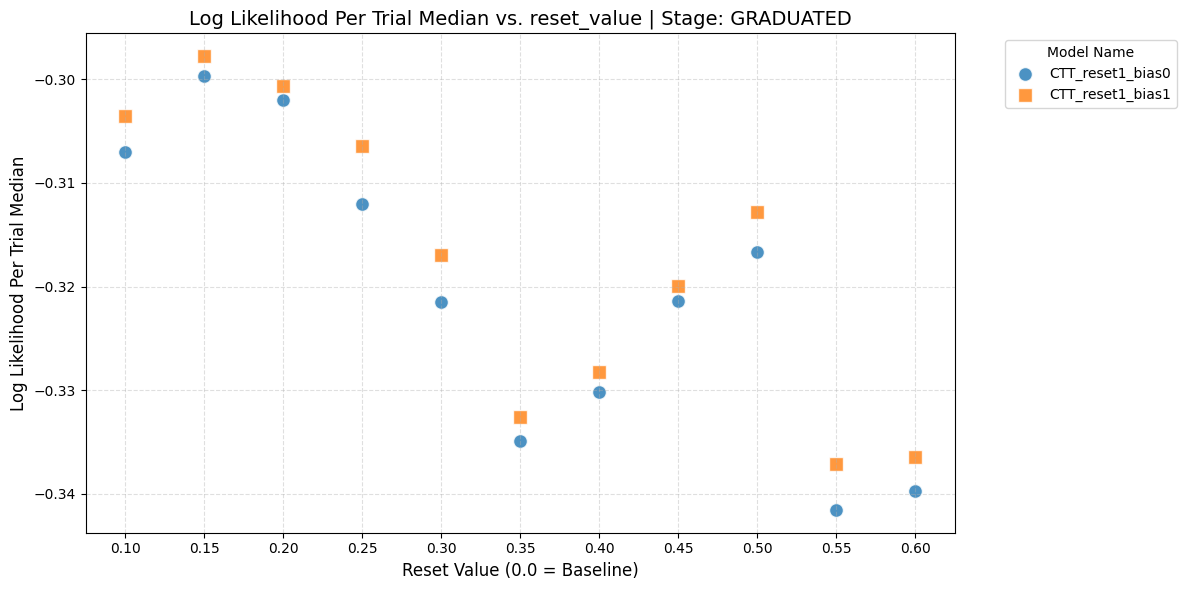

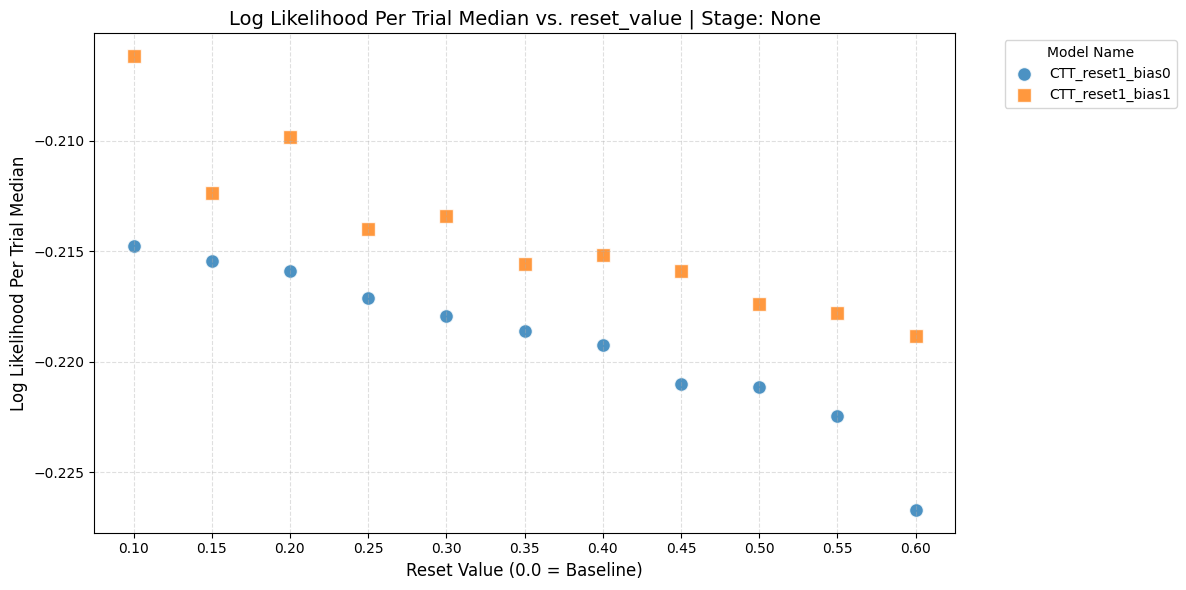

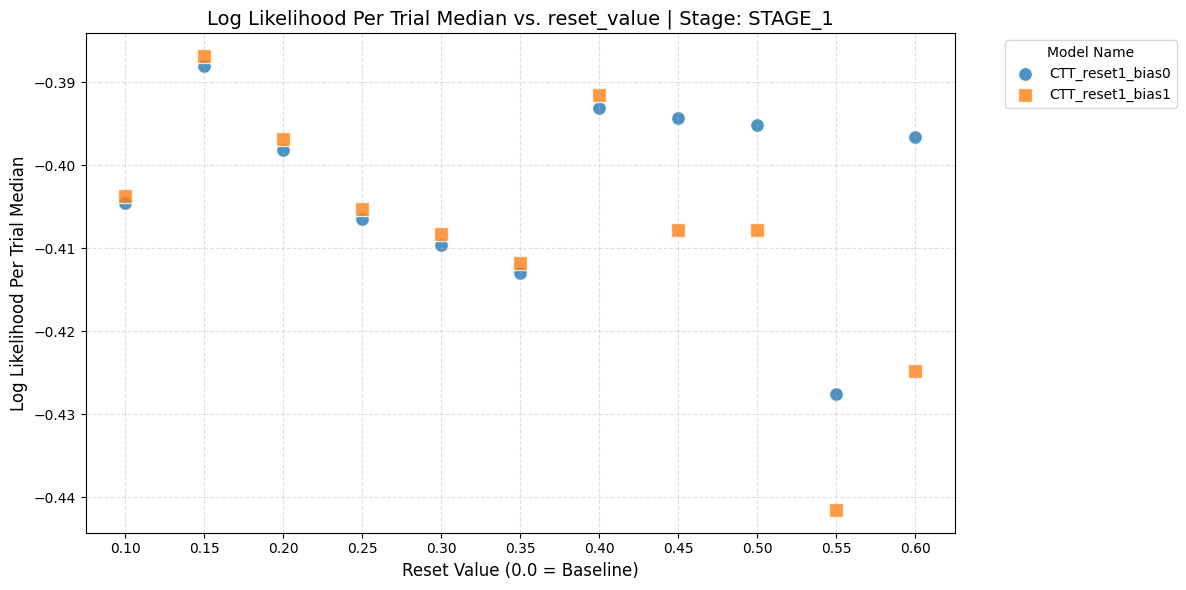

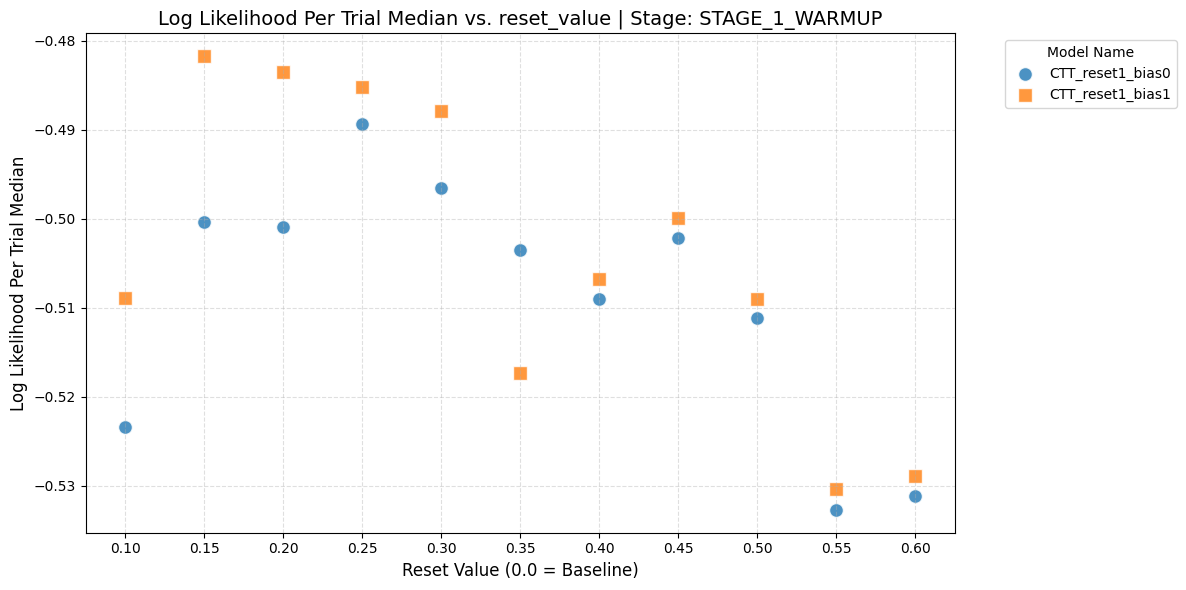

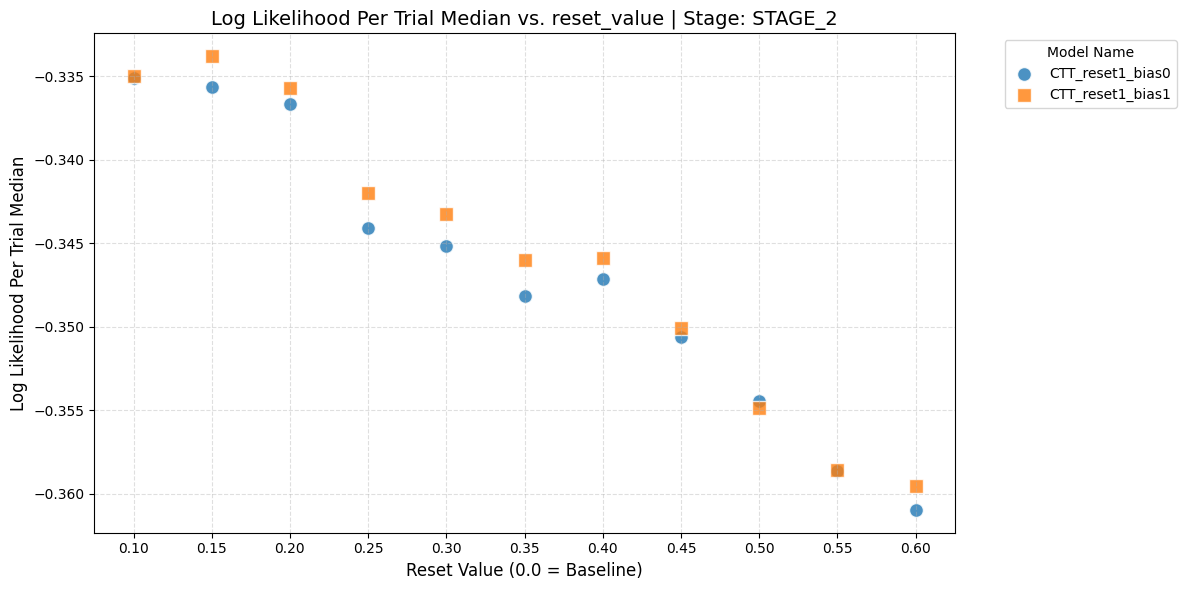

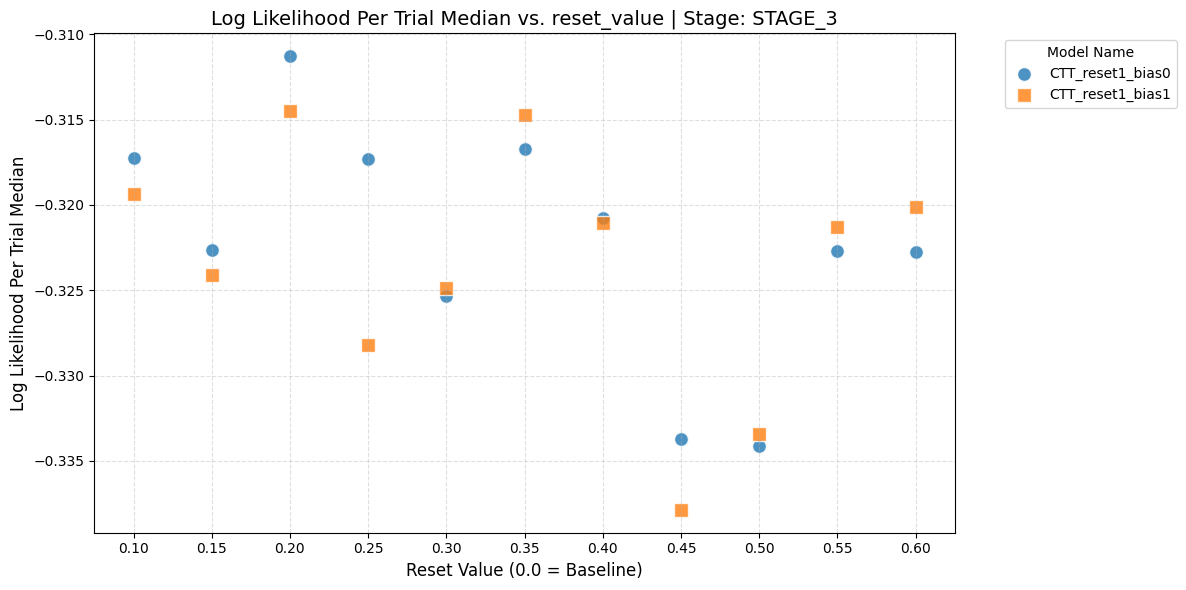

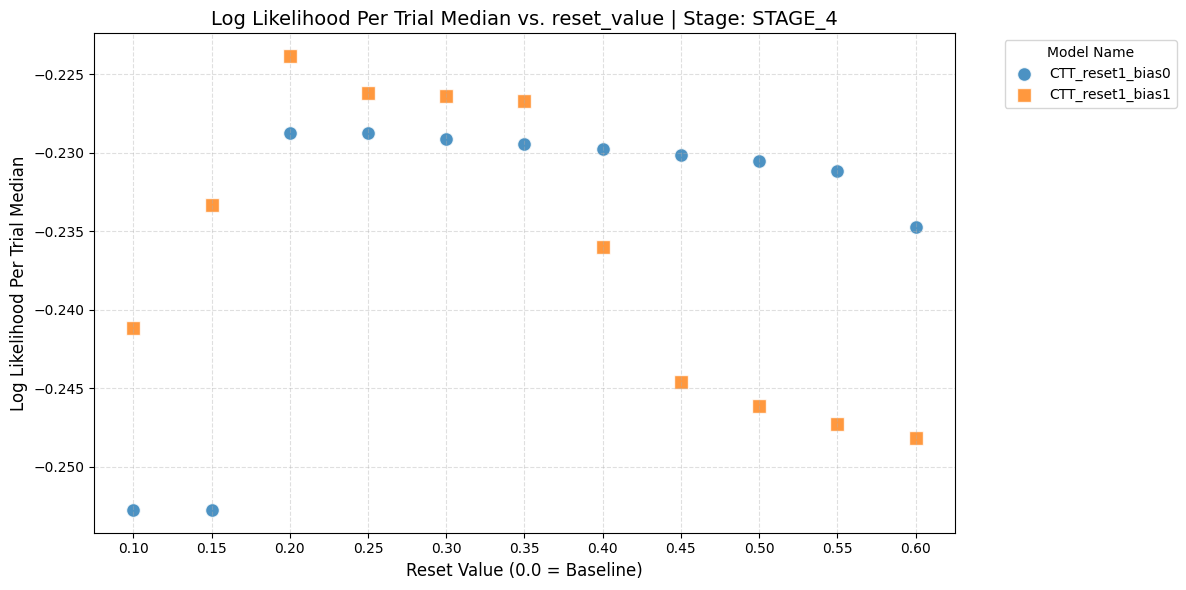

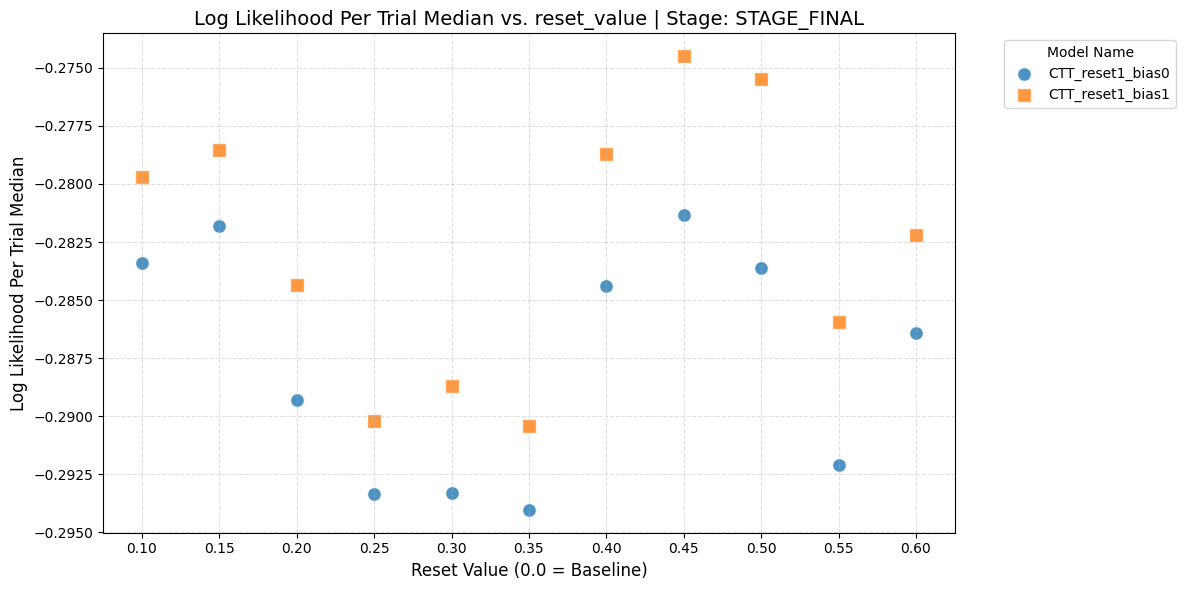

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- CONFIGURATION VARIABLES ---
x_col = 'reset_value'                  # The original column with numeric and None values
y_col = 'log_likelihood_per_trial_median' # Options: 'log_likelihood_mean', 'log_likelihood_median', etc.
include_baseline = False                # Set to False to hide the 'None' baseline
# -------------------------------

plot_df = averages.copy()

# 1. Optional Baseline Filtering
if not include_baseline:
    # Works for both actual None and the string 'None' if it was converted
    plot_df = plot_df.dropna(subset=[x_col])

# 2. Prepare numeric x-axis for plotting
# Maps None/NaN to 0.0 for consistent positioning on the left
plot_df['x_plot_values'] = pd.to_numeric(plot_df[x_col], errors='coerce').fillna(0.0)

# Get unique categories
stages = sorted(plot_df['auto_train_stage'].unique())
models = plot_df['model_name'].unique()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
markers = ['o', 's', 'D', '^', 'v']

# Prepare X-axis ticks and labels dynamically
unique_vals = sorted(plot_df['x_plot_values'].unique())
tick_labels = ['None' if x == 0.0 else f'{x:.2f}' for x in unique_vals]

# 3. Loop through each stage
for stage in stages:
    plt.figure(figsize=(12, 6))
    stage_df = plot_df[plot_df['auto_train_stage'] == stage]
    
    for i, model in enumerate(models):
        subset = stage_df[stage_df['model_name'] == model]
        
        if subset.empty:
            continue
            
        plt.scatter(
            subset['x_plot_values'], 
            subset[y_col],             # Using the variable defined above
            label=model,
            color=colors[i % len(colors)],
            marker=markers[i % len(markers)],
            s=100,
            alpha=0.8,
            edgecolors='w'
        )

    # Formatting
    clean_y_label = y_col.replace('_', ' ').title()
    plt.title(f'{clean_y_label} vs. {x_col} | Stage: {stage}', fontsize=14)
    plt.xlabel('Reset Value (0.0 = Baseline)', fontsize=12)
    plt.ylabel(clean_y_label, fontsize=12)
    
    plt.xticks(unique_vals, tick_labels)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

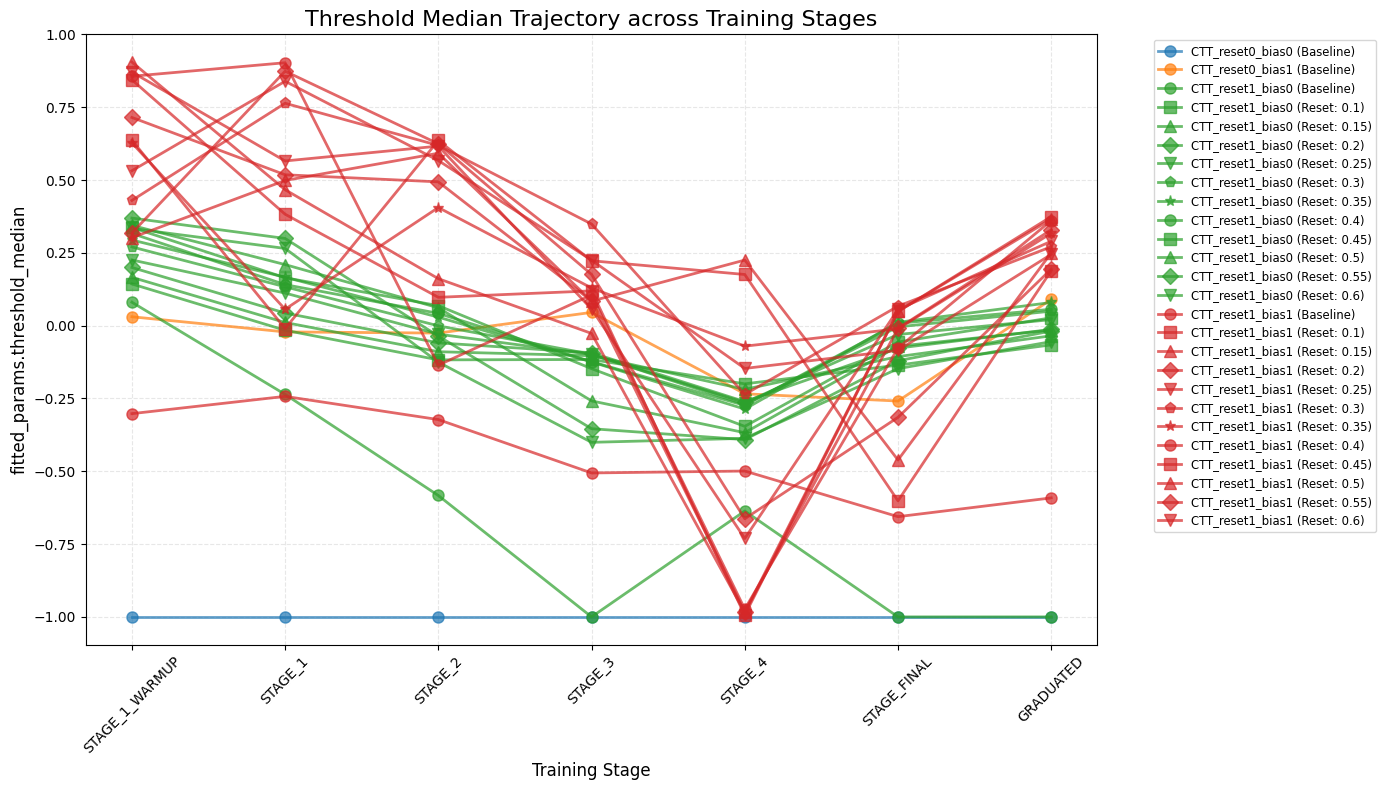

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_threshold_trajectories(df, reset_values_to_include=None):
    """
    Plots the median threshold across training stages for different models and reset values.
    """
    plt.figure(figsize=(14, 8))
    
    # 1. Filter data if specific reset values are requested
    if reset_values_to_include is not None:
        plot_df = df[df['reset_value'].isin(reset_values_to_include)].copy()
    else:
        plot_df = df.copy()

    # 2. Setup styling
    models = plot_df['model_name'].unique()
    # Define unique reset values (handling None/NaN for baseline)
    resets = plot_df['reset_value'].unique()
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    # Different markers for different reset values
    markers = ['o', 's', '^', 'D', 'v', 'p', '*']
    
    # 3. Plotting loop
    for i, model in enumerate(models):
        model_df = plot_df[plot_df['model_name'] == model]
        color = colors[i % len(colors)]
        
        for j, rv in enumerate(resets):
            # Handle the NaN/None case for filtering
            if pd.isna(rv):
                subset = model_df[model_df['reset_value'].isna()]
                label_name = f"{model} (Baseline)"
            else:
                subset = model_df[model_df['reset_value'] == rv]
                label_name = f"{model} (Reset: {rv})"
            
            if subset.empty:
                continue
                
            # Sort by stage index to ensure lines connect correctly
            subset = subset.sort_values('auto_train_stage_idx')
            
            # Plot line and points
            plt.plot(
                subset['auto_train_stage_idx'], 
                subset['fitted_params.threshold_median'],
                marker=markers[j % len(markers)],
                markersize=8,
                linewidth=2,
                alpha=0.7,
                color=color,
                label=label_name
            )

    # 4. Customizing the X-axis labels
    # Map the indices back to the original stage names for the ticks
    tick_mapping = df[['auto_train_stage_idx', 'auto_train_stage']].drop_duplicates().sort_values('auto_train_stage_idx')
    plt.xticks(tick_mapping['auto_train_stage_idx'], tick_mapping['auto_train_stage'], rotation=45)

    # Formatting
    plt.title('Threshold Median Trajectory across Training Stages', fontsize=16)
    plt.xlabel('Training Stage', fontsize=12)
    plt.ylabel('fitted_params.threshold_median', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Move legend outside because there will be many combinations
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=1)
    
    plt.tight_layout()
    plt.show()

# --- HOW TO USE ---
# Plot everything:
plot_threshold_trajectories(averages)

# Or plot only specific reset values for clarity:
# plot_threshold_trajectories(averages, reset_values_to_include=[None, 0.2, 0.5])

In [23]:
import os
import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import concurrent.futures as cf

from nwb_utils import NWBUtils


ROOT_BEHAVIOR = Path("/root/capsule/scratch/general_behavior")


def _session_id_to_nwb_path(session_id: Union[str, Path], root: Path = ROOT_BEHAVIOR) -> Path:
    sid = str(session_id).strip()
    sid_path = Path(sid)
    if sid_path.suffix.lower() == ".nwb":
        return sid_path

    base = sid[:-5] if sid.lower().endswith(".json") else sid
    m = re.search(r"(?P<animal>\d{6,})", base)
    if not m:
        raise ValueError(f"Could not parse animal_id from session_id: {session_id}")
    animal_id = m.group("animal")

    if base.startswith("behavior_"):
        base = base[len("behavior_") :]

    if not base.startswith(f"{animal_id}_"):
        mt = re.search(r"\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}", base)
        if mt is None:
            raise ValueError(
                f"Could not reconstruct NWB filename from session_id: {session_id}. "
                "Expected timestamp like YYYY-mm-dd_HH-MM-SS."
            )
        ts = mt.group(0)
        base = f"{animal_id}_{ts}"

    return root / animal_id / f"{base}.nwb"


def compute_post_switch_ll_metrics(
    animal_response_valid: np.ndarray,
    ll_by_trial: np.ndarray,
    *,
    k_list: List[int],
) -> Dict[str, Any]:
    if animal_response_valid.ndim != 1 or ll_by_trial.ndim != 1:
        raise ValueError("animal_response_valid and ll_by_trial must be 1D.")
    if len(animal_response_valid) != len(ll_by_trial):
        raise ValueError("animal_response_valid and ll_by_trial must have the same length.")

    n = int(len(animal_response_valid))
    if n < 2:
        return {"n_trials": n, "n_switches": 0, "by_k": {}}

    switched = np.zeros(n, dtype=bool)
    switched[1:] = animal_response_valid[1:] != animal_response_valid[:-1]
    switch_idx = np.where(switched)[0]

    out: Dict[str, Any] = {"n_trials": n, "n_switches": int(len(switch_idx)), "by_k": {}}

    for k in k_list:
        post_idx: List[int] = []
        for t in switch_idx:
            start = t + 1
            end = min(t + 1 + k, n)
            if start < end:
                post_idx.extend(range(start, end))

        post_idx_arr = np.asarray(sorted(set(post_idx)), dtype=int)
        if post_idx_arr.size == 0:
            out["by_k"][str(k)] = {"n_trials": 0, "mean": None, "median": None}
            continue

        vals = ll_by_trial[post_idx_arr]
        out["by_k"][str(k)] = {
            "n_trials": int(post_idx_arr.size),
            "mean": float(np.mean(vals)),
            "median": float(np.median(vals)),
        }

    return out


# ---------- Workers MUST be top-level (picklable) ----------

def _load_choices_worker(session_id: str) -> Tuple[str, Optional[np.ndarray], Optional[str]]:
    """
    Load NWB once per session_id, return valid choices (NR removed).
    """
    try:
        nwb_path = _session_id_to_nwb_path(session_id)
        nwb_data = NWBUtils.read_behavior_nwb(nwb_full_path=str(nwb_path))
        if nwb_data is None:
            raise RuntimeError(f"NWBUtils.read_behavior_nwb returned None for {nwb_path}")

        animal_response = np.asarray(nwb_data.trials["animal_response"][:], dtype=int)
        valid_mask = animal_response != 2
        choices = animal_response[valid_mask].astype(np.int8, copy=False)

        if not np.all(np.isin(choices, [0, 1])):
            bad = np.unique(choices[~np.isin(choices, [0, 1])])
            raise ValueError(f"Unexpected response codes {bad} in {nwb_path}")

        return session_id, choices, None
    except Exception as e:
        return session_id, None, repr(e)


def _row_metrics_worker(payload: Tuple[Any, ...]) -> List[Dict[str, Any]]:
    """
    Compute post-switch metrics for one row.
    Payload:
      (row_index, session_id, model_name, reset_value_num, reset_label, ll_list, choices, k_list)
    """
    idx, session_id, model_name, reset_value_num, reset_label, ll_list, choices, k_list = payload
    try:
        ll_by_trial = np.asarray(ll_list, dtype=float)
        if ll_by_trial.ndim != 1:
            raise ValueError("log_likelihood_by_trial is not 1D.")
        if len(ll_by_trial) != len(choices):
            raise ValueError(f"Length mismatch: len(ll)={len(ll_by_trial)} len(choices)={len(choices)}")

        metrics = compute_post_switch_ll_metrics(choices, ll_by_trial, k_list=k_list)

        out_rows: List[Dict[str, Any]] = []
        for k in k_list:
            byk = metrics["by_k"].get(str(k), {})
            out_rows.append(
                {
                    "row_index": idx,
                    "session_id": session_id,
                    "model_name": model_name,
                    "reset_value": reset_value_num,
                    "reset_label": reset_label,
                    "K": int(k),
                    "post_n_trials": byk.get("n_trials", 0),
                    "post_ll_mean": byk.get("mean", None),
                    "post_ll_median": byk.get("median", None),
                    "n_switches": metrics.get("n_switches", 0),
                    "status": "ok",
                    "error": None,
                }
            )
        return out_rows
    except Exception as e:
        return [
            {
                "row_index": idx,
                "session_id": session_id,
                "model_name": model_name,
                "reset_value": reset_value_num,
                "reset_label": reset_label,
                "K": None,
                "post_n_trials": None,
                "post_ll_mean": None,
                "post_ll_median": None,
                "n_switches": None,
                "status": "error",
                "error": repr(e),
            }
        ]


# ---------- Main parallel driver ----------

def analyze_post_switch_parallel(
    combined_df: pd.DataFrame,
    *,
    stage_filter: Optional[str] = "GRADUATED",
    k_list: List[int] = [1, 2, 3, 5, 10],
    max_workers_load: Optional[int] = 8,
    max_workers_rows: Optional[int] = 24,
) -> pd.DataFrame:
    df = combined_df.copy()
    if stage_filter is not None and "auto_train_stage" in df.columns:
        df = df[df["auto_train_stage"].astype(str) == str(stage_filter)].copy()

    for c in ["session_id", "model_name", "log_likelihood_by_trial"]:
        if c not in df.columns:
            raise ValueError(f"combined_df must contain column '{c}'.")

    # A) Load choices once per unique session_id (parallel)
    unique_sessions = sorted(df["session_id"].astype(str).unique().tolist())

    choices_cache: Dict[str, np.ndarray] = {}
    session_errors: Dict[str, str] = {}

    with cf.ProcessPoolExecutor(max_workers=max_workers_load) as ex:
        futures = [ex.submit(_load_choices_worker, sid) for sid in unique_sessions]
        for fut in cf.as_completed(futures):
            sid, choices, err = fut.result()
            if err is None and choices is not None:
                choices_cache[sid] = choices
            else:
                session_errors[sid] = err or "Unknown error"

    # B) Build payloads for row workers
    payloads: List[Tuple[Any, ...]] = []
    error_rows: List[Dict[str, Any]] = []

    for idx, row in df.iterrows():
        session_id = str(row["session_id"])
        model_name = str(row["model_name"])

        reset_value_raw = row.get("fitted_params.reset_value", np.nan)
        if isinstance(reset_value_raw, (float, np.floating)) and np.isnan(reset_value_raw):
            reset_label = "threshold"
            reset_value_num = np.nan
        else:
            try:
                reset_value_num = float(reset_value_raw)
                reset_label = reset_value_num
            except Exception:
                reset_value_num = np.nan
                reset_label = "unknown"

        ll_list = row["log_likelihood_by_trial"]

        if session_id not in choices_cache:
            error_rows.append(
                {
                    "row_index": idx,
                    "session_id": session_id,
                    "model_name": model_name,
                    "reset_value": reset_value_num,
                    "reset_label": reset_label,
                    "K": None,
                    "post_n_trials": None,
                    "post_ll_mean": None,
                    "post_ll_median": None,
                    "n_switches": None,
                    "status": "error",
                    "error": f"NWB load failed: {session_errors.get(session_id, 'unknown')}",
                }
            )
            continue

        payloads.append(
            (idx, session_id, model_name, reset_value_num, reset_label, ll_list, choices_cache[session_id], k_list)
        )

    # C) Compute per-row metrics (parallel)
    out_rows: List[Dict[str, Any]] = []
    out_rows.extend(error_rows)

    # NOTE: This step is usually fast; parallelize only if you have many rows
    with cf.ProcessPoolExecutor(max_workers=max_workers_rows) as ex:
        futures = [ex.submit(_row_metrics_worker, p) for p in payloads]
        for fut in cf.as_completed(futures):
            out_rows.extend(fut.result())

    return pd.DataFrame(out_rows)


def plot_post_switch_ll(
    post_df: pd.DataFrame,
    *,
    metric: str = "post_ll_median",
    k_to_plot: int = 1,
    title: Optional[str] = None,
) -> None:
    if metric not in ("post_ll_median", "post_ll_mean"):
        raise ValueError("metric must be 'post_ll_median' or 'post_ll_mean'.")

    dfk = post_df[(post_df["status"] == "ok") & (post_df["K"] == int(k_to_plot))].copy()
    if dfk.empty:
        print(f"No OK data to plot for K={k_to_plot}.")
        return

    numeric_vals = dfk.loc[dfk["reset_label"] != "threshold", "reset_value"].dropna().unique()
    numeric_vals = np.asarray(sorted(numeric_vals), dtype=float)

    if numeric_vals.size > 0:
        step = float(np.min(np.diff(numeric_vals))) if numeric_vals.size >= 2 else 0.05
        x_threshold = float(numeric_vals.min() - step)
    else:
        x_threshold = -0.05

    dfk["x_plot"] = dfk.apply(lambda r: x_threshold if r["reset_label"] == "threshold" else float(r["reset_value"]), axis=1)

    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111)

    for model_name, g in dfk.groupby("model_name"):
        ax.scatter(g["x_plot"].to_numpy(), g[metric].to_numpy(), label=model_name, alpha=0.85)

    xticks = [x_threshold] + numeric_vals.tolist()
    xticklabels = ["threshold"] + [f"{v:.2f}" for v in numeric_vals.tolist()]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)

    ax.set_xlabel("Reset value (threshold vs fixed prior)")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(title or f"{metric.replace('_', ' ').title()} vs reset_value (K={k_to_plot})")
    ax.legend(loc="best")
    ax.grid(True)
    plt.tight_layout()
    plt.show()


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional


def plot_post_switch_ll_session_average(
    post_df: pd.DataFrame,
    *,
    metric: str = "post_ll_median",
    k_to_plot: int = 1,
    title: Optional[str] = None,
) -> None:
    """
    Plot session-averaged post-switch LL (mean ± SEM across sessions) vs reset value.

    - Fixed reset values: connected line + circle markers
    - Threshold reset: isolated square marker (not connected)
    - Same color for same model_name across both reset types
    - Legend: one entry per model_name
    """
    if metric not in ("post_ll_median", "post_ll_mean"):
        raise ValueError("metric must be 'post_ll_median' or 'post_ll_mean'.")

    df = post_df[(post_df["status"] == "ok") & (post_df["K"] == int(k_to_plot))].copy()
    if df.empty:
        print(f"No OK data to plot for K={k_to_plot}.")
        return

    # 1) Average within session first (avoid sessions with more switches dominating)
    session_df = (
        df.groupby(["session_id", "model_name", "reset_label"], as_index=False)
          .agg(value=(metric, "mean"))
    )

    # 2) Average across sessions
    summary_df = (
        session_df.groupby(["model_name", "reset_label"], as_index=False)
                  .agg(
                      mean=("value", "mean"),
                      sem=("value", lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 0.0),
                      n_sessions=("value", "count"),
                  )
    )

    # X-axis: put "threshold" at a numeric position left of the smallest fixed reset value
    fixed_vals = summary_df.loc[summary_df["reset_label"] != "threshold", "reset_label"]
    fixed_vals = fixed_vals.astype(float, errors="ignore")
    fixed_vals = pd.to_numeric(fixed_vals, errors="coerce").dropna().to_numpy()
    fixed_vals = np.asarray(sorted(np.unique(fixed_vals)), dtype=float)

    if fixed_vals.size > 0:
        step = float(np.min(np.diff(fixed_vals))) if fixed_vals.size >= 2 else 0.05
        x_threshold = float(fixed_vals.min() - step)
    else:
        x_threshold = -0.05

    def _x_map(lbl) -> float:
        return x_threshold if lbl == "threshold" else float(lbl)

    summary_df["x_plot"] = summary_df["reset_label"].apply(_x_map)

    # Stable color per model_name
    model_names = sorted(summary_df["model_name"].unique().tolist())
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = {m: color_cycle[i % len(color_cycle)] for i, m in enumerate(model_names)}

    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111)

    # Plot each model with consistent color; threshold as isolated point
    for model_name, g in summary_df.groupby("model_name"):
        color = color_map[model_name]

        g_fixed = g[g["reset_label"] != "threshold"].sort_values("x_plot")
        has_fixed = not g_fixed.empty

        if has_fixed:
            ax.errorbar(
                g_fixed["x_plot"].to_numpy(),
                g_fixed["mean"].to_numpy(),
                yerr=g_fixed["sem"].to_numpy(),
                marker="o",
                linestyle="-",
                capsize=4,
                color=color,
                label=model_name,  # legend entry from fixed curve
            )

        g_th = g[g["reset_label"] == "threshold"]
        if not g_th.empty:
            ax.errorbar(
                g_th["x_plot"].to_numpy(),
                g_th["mean"].to_numpy(),
                yerr=g_th["sem"].to_numpy(),
                marker="s",
                linestyle="none",
                markersize=7,
                capsize=4,
                color=color,
                # If there is no fixed curve, use the threshold point to create the legend entry
                label=(model_name if not has_fixed else None),
            )


    # Axis ticks/labels
    xticks = [x_threshold] + fixed_vals.tolist()
    xticklabels = ["threshold"] + [f"{v:.2f}" for v in fixed_vals.tolist()]
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)

    ax.set_xlabel("Reset value (threshold vs fixed prior)")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(title or f"Session-averaged post-switch LL (K={k_to_plot})")
    ax.grid(True)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


In [21]:
post_df

,row_index,session_id,model_name,reset_value,reset_label,K,post_n_trials,post_ll_mean,post_ll_median,n_switches,status,error
0,1458,behavior_739195_2024-12-11_17-44-42.json,CTT_reset1_bias0,0.1,0.1,NaN,NaN,NaN,NaN,NaN,error,NWB load failed: RuntimeError('NWBUtils.read_b...
1,1459,behavior_739195_2024-12-12_19-04-52.json,CTT_reset1_bias0,0.1,0.1,NaN,NaN,NaN,NaN,NaN,error,NWB load failed: RuntimeError('NWBUtils.read_b...
2,1460,behavior_739195_2024-12-13_15-40-00.json,CTT_reset1_bias0,0.1,0.1,NaN,NaN,NaN,NaN,NaN,error,NWB load failed: RuntimeError('NWBUtils.read_b...
3,1461,behavior_739195_2024-12-16_16-38-15.json,CTT_reset1_bias0,0.1,0.1,NaN,NaN,NaN,NaN,NaN,error,NWB load failed: RuntimeError('NWBUtils.read_b...
4,1462,behavior_739195_2024-12-17_17-58-46.json,CTT_reset1_bias0,0.1,0.1,NaN,NaN,NaN,NaN,NaN,error,NWB load failed: RuntimeError('NWBUtils.read_b...
...,...,...,...,...,...,...,...,...,...,...,...,...
68432,33499,763704_2025-02-27_18-26-39.json,CTT_reset1_bias1,NaN,threshold,1.0,125.0,-0.667487,-0.430907,125.0,ok,None
68433,33499,763704_2025-02-27_18-26-39.json,CTT_reset1_bias1,NaN,threshold,2.0,201.0,-0.651285,-0.430907,125.0,ok,None
68434,33499,763704_2025-02-27_18-26-39.json,CTT_reset1_bias1,NaN,threshold,3.0,253.0,-0.645388,-0.430907,125.0,ok,None
68435,33499,763704_2025-02-27_18-26-39.json,CTT_reset1_bias1,NaN,threshold,5.0,315.0,-0.632042,-0.430907,125.0,ok,None


In [ ]:
post_df = analyze_post_switch_parallel(
    combined_df,
    stage_filter="GRADUATED",
    k_list=[1, 2, 3, 5, 10],
    max_workers_load=8,
    max_workers_rows=24,
)

# Inspect errors
err_df = post_df[post_df["status"] == "error"][["session_id", "model_name", "error"]].drop_duplicates()
print("Unique errors:", len(err_df))
display(err_df.head(20))

# Plot
plot_post_switch_ll(post_df, metric="post_ll_median", k_to_plot=1)


Unique errors: 176


,session_id,model_name,error
0,behavior_739195_2024-12-11_17-44-42.json,CTT_reset1_bias0,NWB load failed: RuntimeError('NWBUtils.read_b...
1,behavior_739195_2024-12-12_19-04-52.json,CTT_reset1_bias0,NWB load failed: RuntimeError('NWBUtils.read_b...
2,behavior_739195_2024-12-13_15-40-00.json,CTT_reset1_bias0,NWB load failed: RuntimeError('NWBUtils.read_b...
3,behavior_739195_2024-12-16_16-38-15.json,CTT_reset1_bias0,NWB load failed: RuntimeError('NWBUtils.read_b...
4,behavior_739195_2024-12-17_17-58-46.json,CTT_reset1_bias0,NWB load failed: RuntimeError('NWBUtils.read_b...
5,behavior_739195_2024-12-11_17-44-42.json,CTT_reset1_bias1,NWB load failed: RuntimeError('NWBUtils.read_b...
6,behavior_739195_2024-12-12_19-04-52.json,CTT_reset1_bias1,NWB load failed: RuntimeError('NWBUtils.read_b...
7,behavior_739195_2024-12-13_15-40-00.json,CTT_reset1_bias1,NWB load failed: RuntimeError('NWBUtils.read_b...
8,behavior_739195_2024-12-16_16-38-15.json,CTT_reset1_bias1,NWB load failed: RuntimeError('NWBUtils.read_b...
9,behavior_739195_2024-12-17_17-58-46.json,CTT_reset1_bias1,NWB load failed: RuntimeError('NWBUtils.read_b...


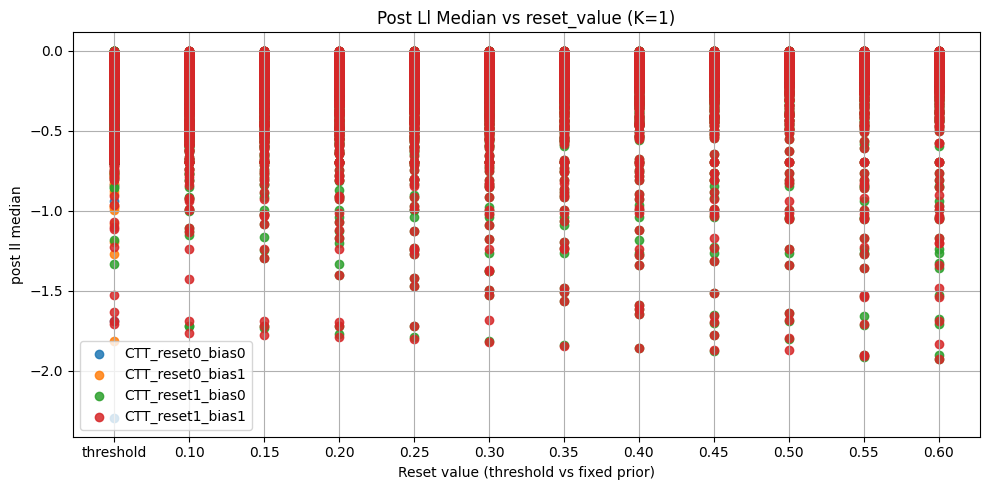

In [14]:
# Inspect errors
err_df = post_df[post_df["status"] == "error"][["session_id", "model_name", "error"]].drop_duplicates()
print("Unique errors:", len(err_df))
display(err_df.head(20))

# Plot
plot_post_switch_ll(post_df, metric="post_ll_median", k_to_plot=1)

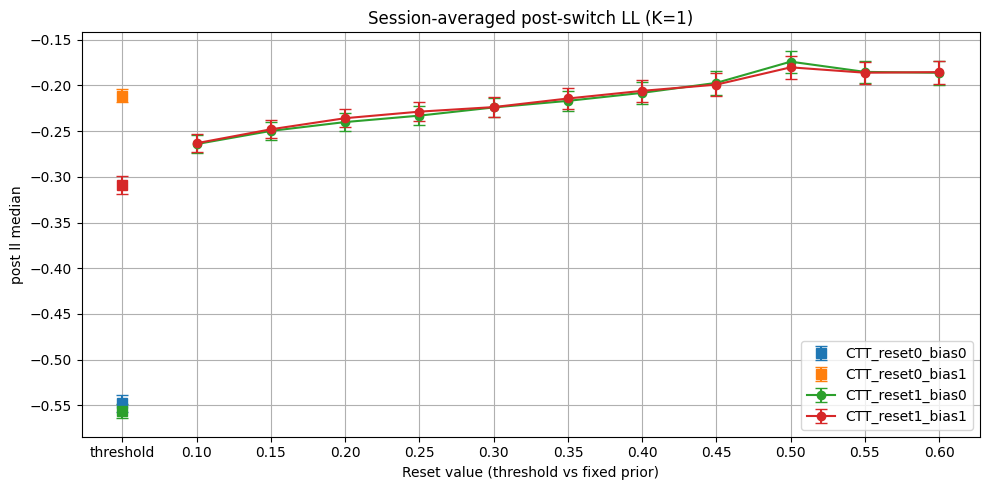

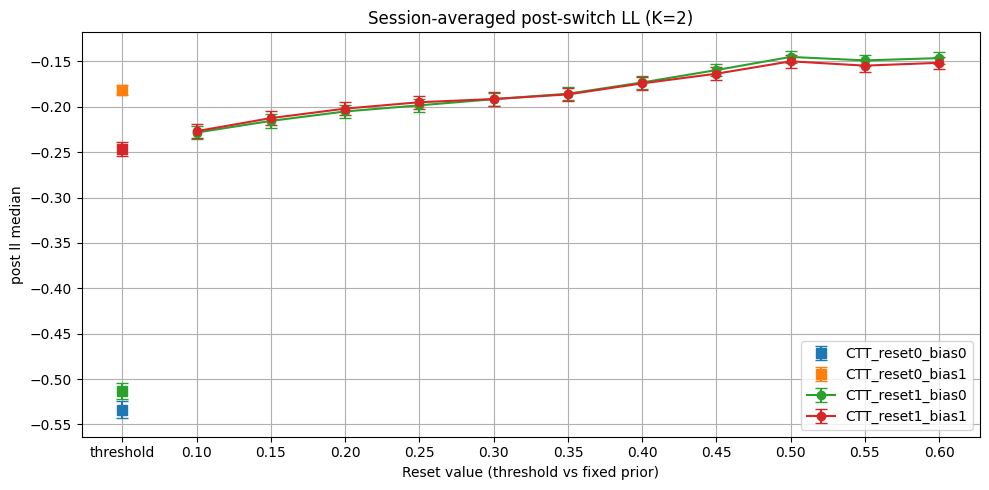

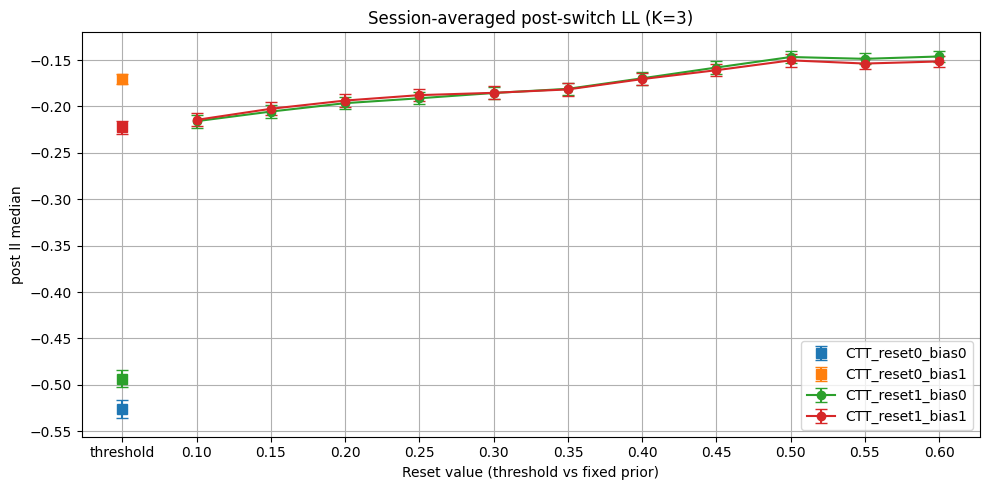

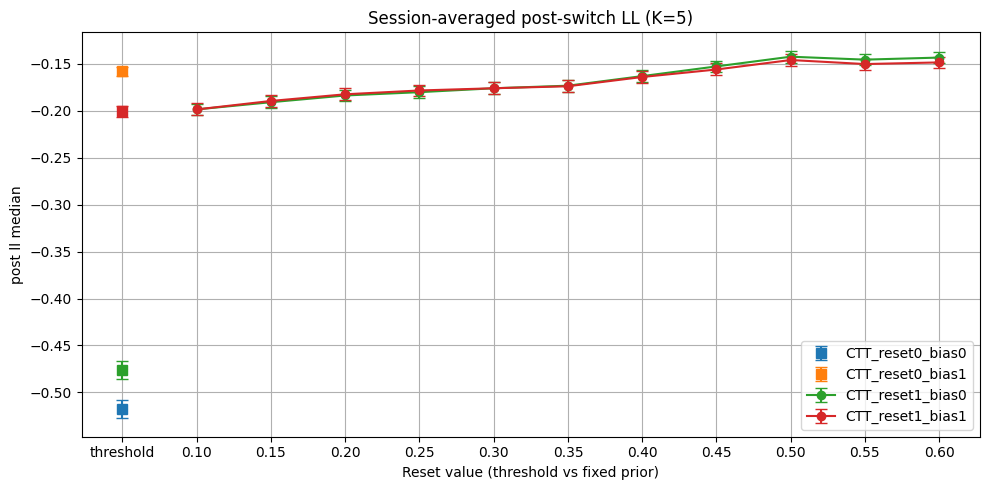

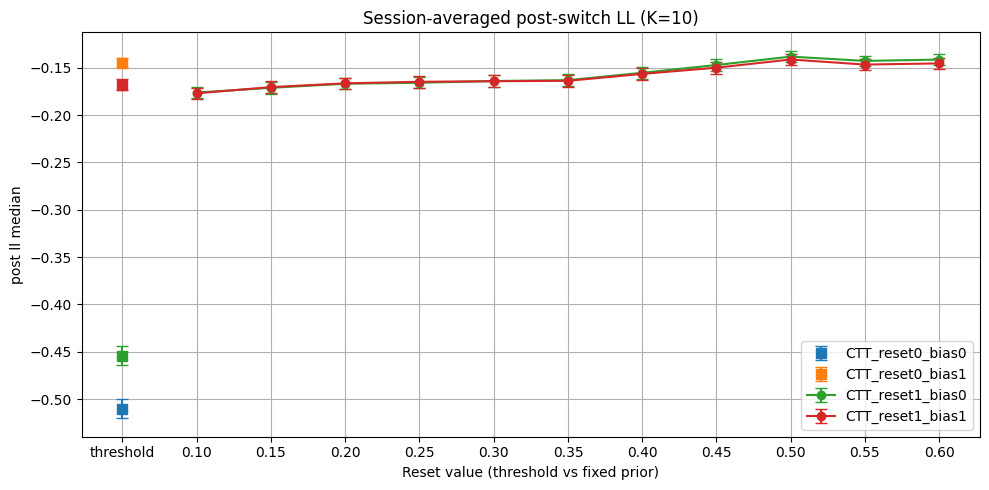

In [24]:
# K=1 is the most sensitive (first trial after switch)
plot_post_switch_ll_session_average(
    post_df,
    metric="post_ll_median",
    k_to_plot=1,
    title="Session-averaged post-switch LL (K=1)",
)

# Also check K=2 for stability
plot_post_switch_ll_session_average(
    post_df,
    metric="post_ll_median",
    k_to_plot=2,
    title="Session-averaged post-switch LL (K=2)",
)


plot_post_switch_ll_session_average(
    post_df,
    metric="post_ll_median",
    k_to_plot=3,
    title="Session-averaged post-switch LL (K=3)",
)

plot_post_switch_ll_session_average(
    post_df,
    metric="post_ll_median",
    k_to_plot=5,
    title="Session-averaged post-switch LL (K=5)",
)


plot_post_switch_ll_session_average(
    post_df,
    metric="post_ll_median",
    k_to_plot=10,
    title="Session-averaged post-switch LL (K=10)",
)


In [37]:
import os
import re
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import concurrent.futures as cf

from nwb_utils import NWBUtils


ROOT_BEHAVIOR = Path("/root/capsule/scratch/general_behavior")


def _session_id_to_nwb_path(session_id: Union[str, Path], root: Path = ROOT_BEHAVIOR) -> Path:
    sid = str(session_id).strip()
    sid_path = Path(sid)
    if sid_path.suffix.lower() == ".nwb":
        return sid_path

    base = sid[:-5] if sid.lower().endswith(".json") else sid
    m = re.search(r"(?P<animal>\d{6,})", base)
    if not m:
        raise ValueError(f"Could not parse animal_id from session_id: {session_id}")
    animal_id = m.group("animal")

    if base.startswith("behavior_"):
        base = base[len("behavior_") :]

    if not base.startswith(f"{animal_id}_"):
        mt = re.search(r"\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}", base)
        if mt is None:
            raise ValueError(
                f"Could not reconstruct NWB filename from session_id: {session_id}. "
                "Expected timestamp like YYYY-mm-dd_HH-MM-SS."
            )
        ts = mt.group(0)
        base = f"{animal_id}_{ts}"

    return root / animal_id / f"{base}.nwb"


def compute_post_switch_ll_by_lag(
    animal_response_valid: np.ndarray,
    ll_by_trial: np.ndarray,
    *,
    k_max: int,
) -> Dict[str, Any]:
    """
    Compute post-switch log-likelihood as a function of lag after a switch.

    Definitions
    ----------
    A switch occurs at trial t if choice[t] != choice[t-1] (t>=1).
    For each switch at t, we look at post-switch trials:
        t+1 is lag=1, t+2 is lag=2, ..., t+k_max is lag=k_max (if in bounds)

    Output
    ------
    by_lag_mean:   length k_max list, mean LL across switch events for each lag (NaN if no samples)
    by_lag_median: length k_max list, median LL across switch events for each lag (NaN if no samples)
    by_lag_n:      length k_max list, number of samples for each lag
    """
    if animal_response_valid.ndim != 1 or ll_by_trial.ndim != 1:
        raise ValueError("animal_response_valid and ll_by_trial must be 1D.")
    if len(animal_response_valid) != len(ll_by_trial):
        raise ValueError("animal_response_valid and ll_by_trial must have the same length.")
    if k_max <= 0:
        raise ValueError("k_max must be >= 1.")

    n = int(len(animal_response_valid))
    if n < 2:
        return {
            "n_trials": n,
            "n_switches": 0,
            "by_lag_mean": [float("nan")] * k_max,
            "by_lag_median": [float("nan")] * k_max,
            "by_lag_n": [0] * k_max,
        }

    switched = np.zeros(n, dtype=bool)
    switched[1:] = animal_response_valid[1:] != animal_response_valid[:-1]
    switch_idx = np.where(switched)[0]  # trials where the switch is observed

    # Collect LL values per lag
    buckets: List[List[float]] = [[] for _ in range(k_max)]
    for t in switch_idx:
        for lag in range(1, k_max + 1):
            j = t + lag
            if j < n:
                buckets[lag - 1].append(float(ll_by_trial[j]))

    by_lag_mean = []
    by_lag_median = []
    by_lag_n = []

    for vals in buckets:
        by_lag_n.append(int(len(vals)))
        if len(vals) == 0:
            by_lag_mean.append(float("nan"))
            by_lag_median.append(float("nan"))
        else:
            arr = np.asarray(vals, dtype=float)
            by_lag_mean.append(float(np.mean(arr)))
            by_lag_median.append(float(np.median(arr)))

    return {
        "n_trials": n,
        "n_switches": int(len(switch_idx)),
        "by_lag_mean": by_lag_mean,
        "by_lag_median": by_lag_median,
        "by_lag_n": by_lag_n,
    }


def _load_choices_worker(session_id: str) -> Tuple[str, Optional[np.ndarray], Optional[str]]:
    """
    Load NWB once per session_id, return valid choices (NR removed).
    """
    try:
        nwb_path = _session_id_to_nwb_path(session_id)
        nwb_data = NWBUtils.read_behavior_nwb(nwb_full_path=str(nwb_path))
        if nwb_data is None:
            raise RuntimeError(f"NWBUtils.read_behavior_nwb returned None for {nwb_path}")

        animal_response = np.asarray(nwb_data.trials["animal_response"][:], dtype=int)
        valid_mask = animal_response != 2
        choices = animal_response[valid_mask].astype(np.int8, copy=False)

        if not np.all(np.isin(choices, [0, 1])):
            bad = np.unique(choices[~np.isin(choices, [0, 1])])
            raise ValueError(f"Unexpected response codes {bad} in {nwb_path}")

        return session_id, choices, None
    except Exception as e:
        return session_id, None, repr(e)


def append_post_switch_ll_by_lag_to_combined_df(
    combined_df: pd.DataFrame,
    *,
    stage_filter: Optional[str] = None,
    k_max: int = 10,
    max_workers_load: int = 8,
) -> pd.DataFrame:
    """
    Append per-row post-switch LL-by-lag vectors directly onto combined_df.

    New columns added
    -----------------
    - post_switch_ll_by_lag_mean:   list[float] length k_max (NaN where missing)
    - post_switch_ll_by_lag_median: list[float] length k_max (NaN where missing)
    - post_switch_ll_by_lag_n:      list[int]   length k_max
    - post_switch_n_switches:       int
    - post_switch_status:           "ok" or "error"
    - post_switch_error:            error string or None

    Notes
    -----
    - NWB is loaded once per session_id (parallel) then cached.
    - Row computation is fast (pure numpy), done in the main process.
    """
    df = combined_df.copy()

    if stage_filter is not None and "auto_train_stage" in df.columns:
        df = df[df["auto_train_stage"].astype(str) == str(stage_filter)].copy()

    for c in ["session_id", "model_name", "log_likelihood_by_trial"]:
        if c not in df.columns:
            raise ValueError(f"combined_df must contain column '{c}'.")

    unique_sessions = sorted(df["session_id"].astype(str).unique().tolist())

    # Load choices per session_id (parallel; I/O bound)
    choices_cache: Dict[str, np.ndarray] = {}
    session_errors: Dict[str, str] = {}

    with cf.ProcessPoolExecutor(max_workers=max_workers_load) as ex:
        futures = [ex.submit(_load_choices_worker, sid) for sid in unique_sessions]
        for fut in cf.as_completed(futures):
            sid, choices, err = fut.result()
            if err is None and choices is not None:
                choices_cache[sid] = choices
            else:
                session_errors[sid] = err or "Unknown error"

    # Compute row-level by-lag vectors (main process)
    mean_col = []
    median_col = []
    n_col = []
    n_switches_col = []
    status_col = []
    error_col = []

    for _, row in df.iterrows():
        session_id = str(row["session_id"])

        if session_id not in choices_cache:
            mean_col.append([float("nan")] * k_max)
            median_col.append([float("nan")] * k_max)
            n_col.append([0] * k_max)
            n_switches_col.append(np.nan)
            status_col.append("error")
            error_col.append(f"NWB load failed: {session_errors.get(session_id, 'unknown')}")
            continue

        try:
            ll_by_trial = np.asarray(row["log_likelihood_by_trial"], dtype=float)
            choices = choices_cache[session_id]

            if ll_by_trial.ndim != 1:
                raise ValueError("log_likelihood_by_trial is not 1D.")
            if len(ll_by_trial) != len(choices):
                raise ValueError(f"Length mismatch: len(ll)={len(ll_by_trial)} len(choices)={len(choices)}")

            m = compute_post_switch_ll_by_lag(choices, ll_by_trial, k_max=k_max)

            mean_col.append(m["by_lag_mean"])
            median_col.append(m["by_lag_median"])
            n_col.append(m["by_lag_n"])
            n_switches_col.append(m["n_switches"])
            status_col.append("ok")
            error_col.append(None)

        except Exception as e:
            mean_col.append([float("nan")] * k_max)
            median_col.append([float("nan")] * k_max)
            n_col.append([0] * k_max)
            n_switches_col.append(np.nan)
            status_col.append("error")
            error_col.append(repr(e))

    df["post_switch_ll_by_lag_mean"] = mean_col
    df["post_switch_ll_by_lag_median"] = median_col
    df["post_switch_ll_by_lag_n"] = n_col
    df["post_switch_n_switches"] = n_switches_col
    df["post_switch_status"] = status_col
    df["post_switch_error"] = error_col

    return df

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional


def plot_post_switch_ll_by_lag_vs_reset_value(
    combined_df_with_lag: pd.DataFrame,
    *,
    value_key: str = "post_switch_ll_by_lag_median",  # or "post_switch_ll_by_lag_mean"
    k_max: int = 10,
    stage_filter: Optional[str] = "GRADUATED",
    title_prefix: str = "Session-averaged post-switch LL",
) -> None:
    """
    For each lag=1..k_max, plot session-averaged post-switch LL vs reset_value
    in a separate figure.

    Input requirements
    ------------------
    combined_df_with_lag must contain:
      - session_id, model_name, auto_train_stage (optional), fitted_params.reset_value (optional)
      - value_key: list[float] length>=k_max (per-row lag vector)
      - post_switch_status == "ok" indicates valid rows

    Plot semantics
    --------------
    - Fixed reset values: circle markers connected by a line
    - Threshold reset (reset_value is NaN): square marker, not connected
    - Same color for same model_name across fixed/threshold
    - Averaging: within-session first, then across sessions (mean ± SEM)
    """
    if value_key not in ("post_switch_ll_by_lag_mean", "post_switch_ll_by_lag_median"):
        raise ValueError("value_key must be 'post_switch_ll_by_lag_mean' or 'post_switch_ll_by_lag_median'.")

    df = combined_df_with_lag.copy()

    if stage_filter is not None and "auto_train_stage" in df.columns:
        df = df[df["auto_train_stage"].astype(str) == str(stage_filter)].copy()

    if "post_switch_status" in df.columns:
        df = df[df["post_switch_status"] == "ok"].copy()

    if df.empty:
        print("No OK rows to plot.")
        return

    # Ensure reset_label exists (threshold vs fixed)
    if "reset_label" not in df.columns:
        def _reset_label_from_row(row) -> str:
            rv = row.get("fitted_params.reset_value", np.nan)
            if isinstance(rv, (float, np.floating)) and np.isnan(rv):
                return "threshold"
            try:
                return f"{float(rv):.2f}"
            except Exception:
                return "unknown"
        df["reset_label"] = df.apply(_reset_label_from_row, axis=1)

    # Pre-compute numeric reset values for x-axis ticks
    reset_numeric = (
        df.loc[df["reset_label"] != "threshold", "reset_label"]
        .astype(str)
        .apply(lambda s: float(s) if s not in ("unknown",) else np.nan)
        .dropna()
        .unique()
    )
    reset_numeric = np.asarray(sorted(reset_numeric), dtype=float)

    if reset_numeric.size > 0:
        step = float(np.min(np.diff(reset_numeric))) if reset_numeric.size >= 2 else 0.05
        x_threshold = float(reset_numeric.min() - step)
    else:
        x_threshold = -0.05

    def _x_map(lbl: str) -> float:
        return x_threshold if lbl == "threshold" else float(lbl)

    # Stable color per model_name
    model_names = sorted(df["model_name"].astype(str).unique().tolist())
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    color_map = {m: color_cycle[i % len(color_cycle)] for i, m in enumerate(model_names)}

    # Helper: extract lag value from vector in a row
    def _get_lag_val(vec, lag_index: int) -> float:
        arr = np.asarray(vec, dtype=float)
        if arr.ndim != 1 or arr.size <= lag_index:
            return np.nan
        return float(arr[lag_index])

    # One figure per lag
    for lag in range(1, k_max + 1):
        lag_idx = lag - 1

        # Build per-row scalar for this lag
        df_lag = df.copy()
        df_lag["lag_value"] = df_lag[value_key].apply(lambda v: _get_lag_val(v, lag_idx))

        # Drop missing lag values
        df_lag = df_lag.dropna(subset=["lag_value"])
        if df_lag.empty:
            print(f"No data for lag={lag}.")
            continue

        # Average within session first (avoid sessions with more switches dominating)
        session_df = (
            df_lag.groupby(["session_id", "model_name", "reset_label"], as_index=False)
                  .agg(lag_value=("lag_value", "mean"))
        )

        # Average across sessions
        summary_df = (
            session_df.groupby(["model_name", "reset_label"], as_index=False)
                      .agg(
                          mean=("lag_value", "mean"),
                          sem=("lag_value", lambda x: float(np.std(x, ddof=1) / np.sqrt(len(x))) if len(x) > 1 else 0.0),
                          n_sessions=("lag_value", "count"),
                      )
        )
        summary_df["x_plot"] = summary_df["reset_label"].apply(_x_map)

        # Plot in the same style as your screenshot
        fig = plt.figure(figsize=(10, 5))
        ax = fig.add_subplot(111)

        for model_name, g in summary_df.groupby("model_name"):
            color = color_map[str(model_name)]

            g_fixed = g[g["reset_label"] != "threshold"].sort_values("x_plot")
            has_fixed = not g_fixed.empty

            if has_fixed:
                ax.errorbar(
                    g_fixed["x_plot"].to_numpy(),
                    g_fixed["mean"].to_numpy(),
                    yerr=g_fixed["sem"].to_numpy(),
                    marker="o",
                    linestyle="-",
                    capsize=4,
                    color=color,
                    label=str(model_name),
                )

            g_th = g[g["reset_label"] == "threshold"]
            if not g_th.empty:
                ax.errorbar(
                    g_th["x_plot"].to_numpy(),
                    g_th["mean"].to_numpy(),
                    yerr=g_th["sem"].to_numpy(),
                    marker="s",
                    linestyle="none",
                    markersize=7,
                    capsize=4,
                    color=color,
                    label=(str(model_name) if not has_fixed else None),
                )

        xticks = [x_threshold] + reset_numeric.tolist()
        xticklabels = ["threshold"] + [f"{v:.2f}" for v in reset_numeric.tolist()]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)

        ax.set_xlabel("Reset value (threshold vs fixed prior)")
        ax.set_ylabel("post ll " + ("median" if value_key.endswith("median") else "mean"))
        ax.set_title(f"{title_prefix} (lag={lag}) | Stage: {stage_filter}")
        ax.grid(True)
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()

# -----------------------------
# Example usage
# -----------------------------
# 1) Append lag-vectors onto combined_df
# combined_df2 = append_post_switch_ll_by_lag_to_combined_df(
#     combined_df,
#     stage_filter="GRADUATED",
#     k_max=10,
#     max_workers_load=8,
# )
#
# 2) Plot LL vs lag (1..10)
# plot_post_switch_ll_by_lag_session_average(
#     combined_df2,
#     value_key="post_switch_ll_by_lag_median",
#     k_max=10,
#     stage_filter="GRADUATED",
#     title="Post-switch LL by lag (median), session-averaged | GRADUATED",
# )


Found behavior NWB: /root/capsule/scratch/general_behavior/703548/703548_2024-03-12_12-46-54.nwbFound behavior NWB: /root/capsule/scratch/general_behavior/703548/703548_2024-03-12_13-06-32.nwbFound behavior NWB: /root/capsule/scratch/general_behavior/698694/698694_2024-04-23_09-45-59.nwbFound behavior NWB: /root/capsule/scratch/general_behavior/698694/698694_2024-04-17_12-21-55.nwbFound behavior NWB: /root/capsule/scratch/general_behavior/698694/698694_2024-04-18_12-04-21.nwbFound behavior NWB: /root/capsule/scratch/general_behavior/698694/698694_2024-04-24_09-55-26.nwbFound behavior NWB: /root/capsule/scratch/general_behavior/698694/698694_2024-04-19_11-38-06.nwbFound behavior NWB: /root/capsule/scratch/general_behavior/698694/698694_2024-04-22_10-56-51.nwb







Successfully read behavior NWB from: /root/capsule/scratch/general_behavior/703548/703548_2024-03-12_12-46-54.nwb
Found behavior NWB: /root/capsule/scratch/general_behavior/703548/703548_2024-03-13_11-30-07.nwb
Successfully 

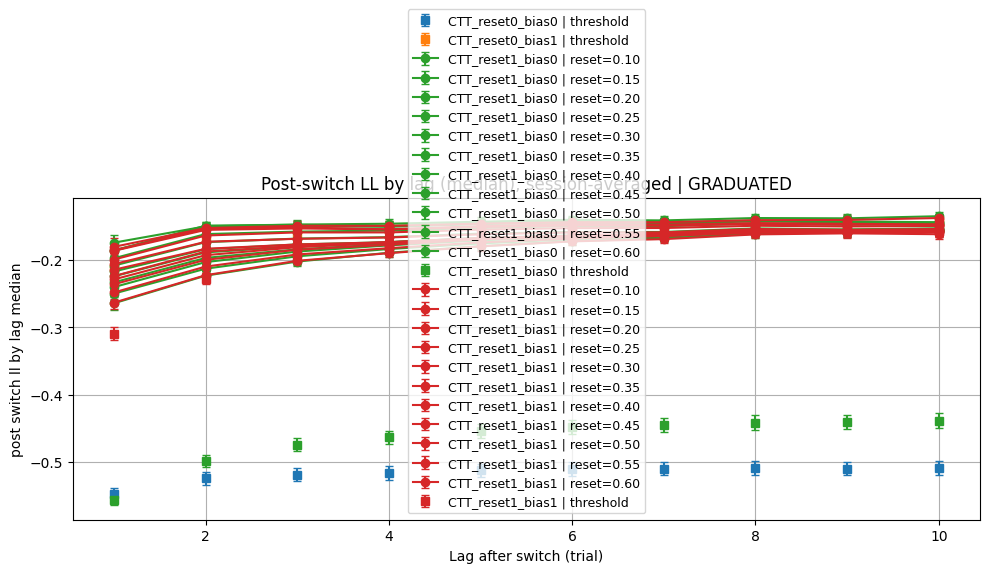

In [38]:
# 1) Append lag-vectors onto combined_df
combined_df2 = append_post_switch_ll_by_lag_to_combined_df(
    combined_df,
    k_max=10,
    max_workers_load=8,
)

# 2) Plot LL vs lag (1..10)
plot_post_switch_ll_by_lag_session_average(
    combined_df2,
    value_key="post_switch_ll_by_lag_median",
    k_max=10,
    stage_filter="GRADUATED",
    title="Post-switch LL by lag (median), session-averaged | GRADUATED",
)


In [ ]:
stage_mapping = {
    'STAGE_1_WARMUP': 0,
    'STAGE_1': 1,
    'STAGE_2': 2,
    'STAGE_3': 3,
    'STAGE_4': 4,
    'STAGE_FINAL': 5,
    'GRADUATED': 6
}

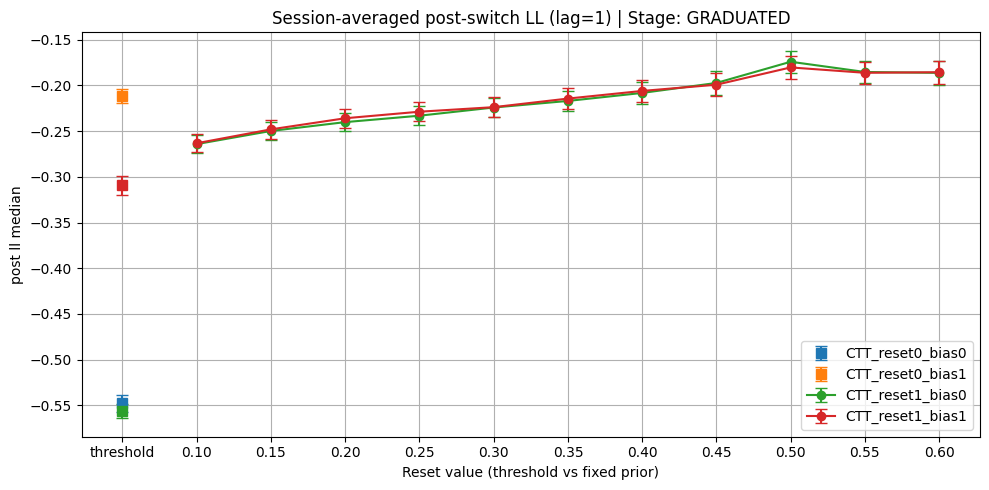

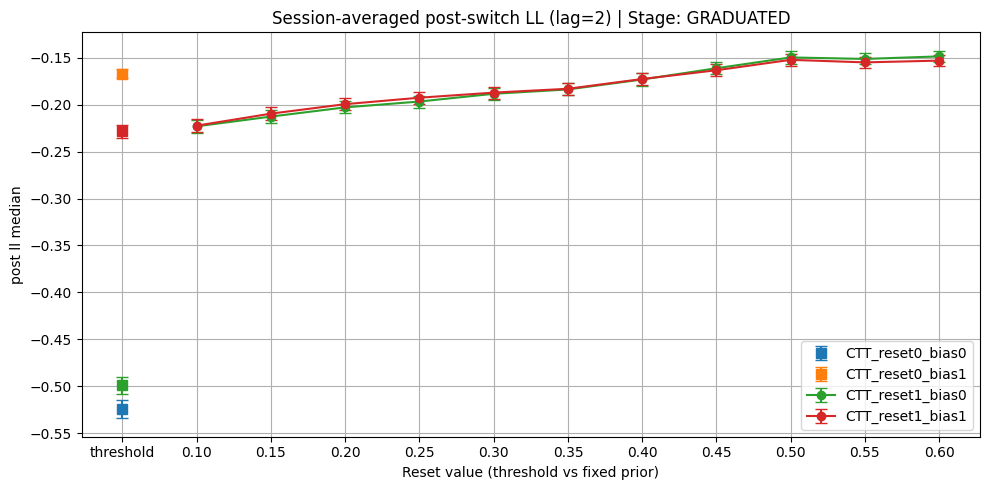

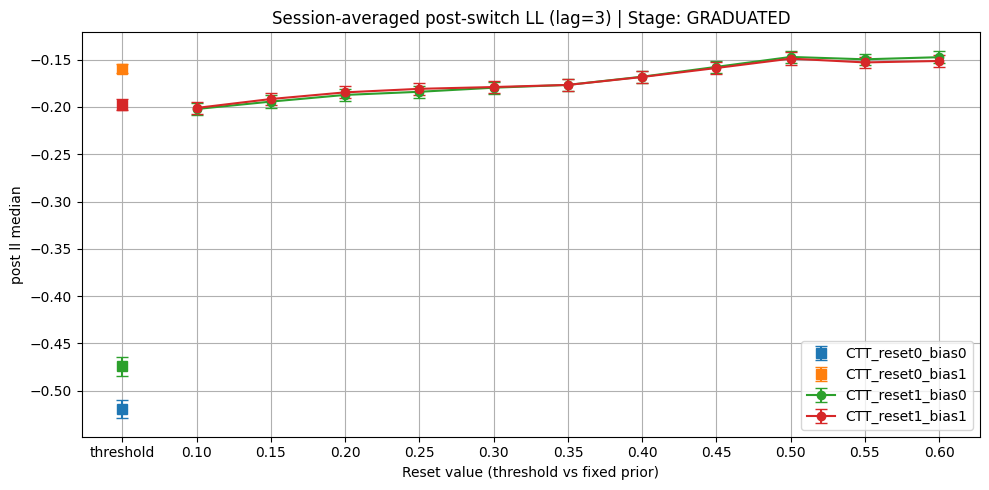

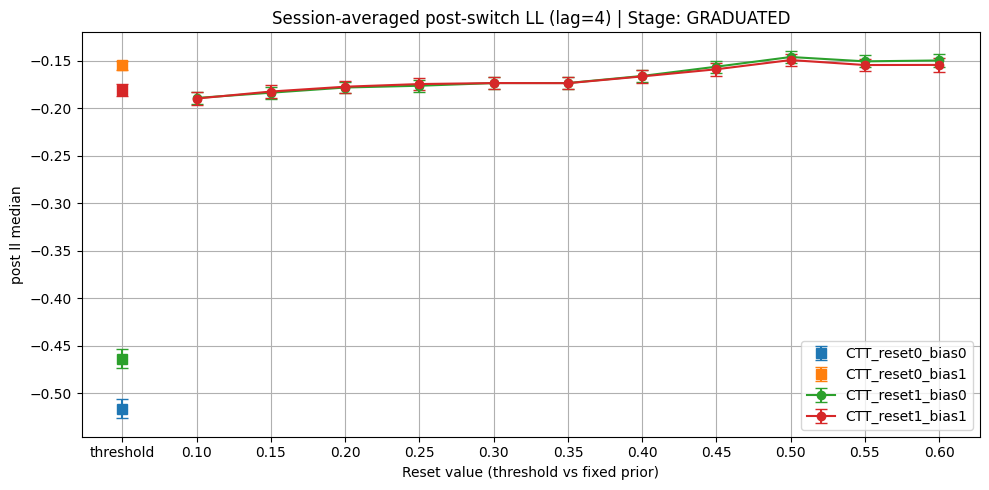

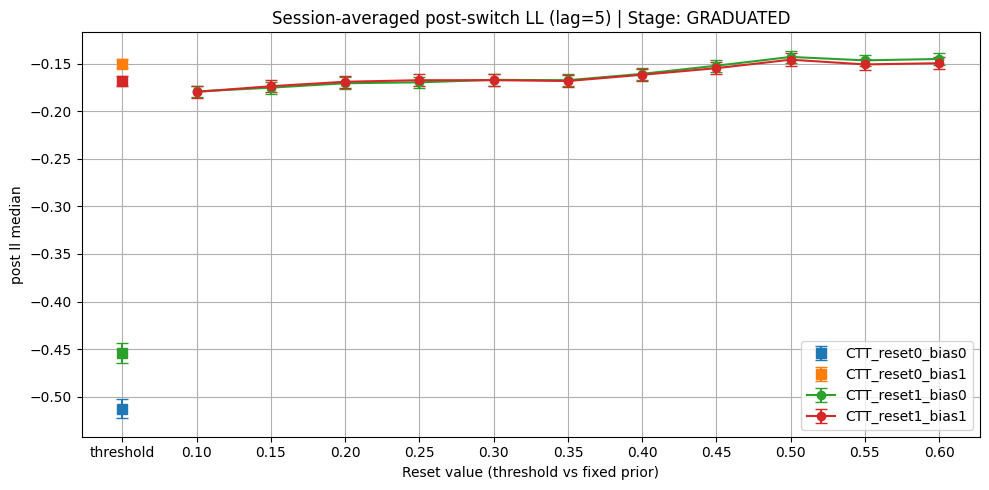

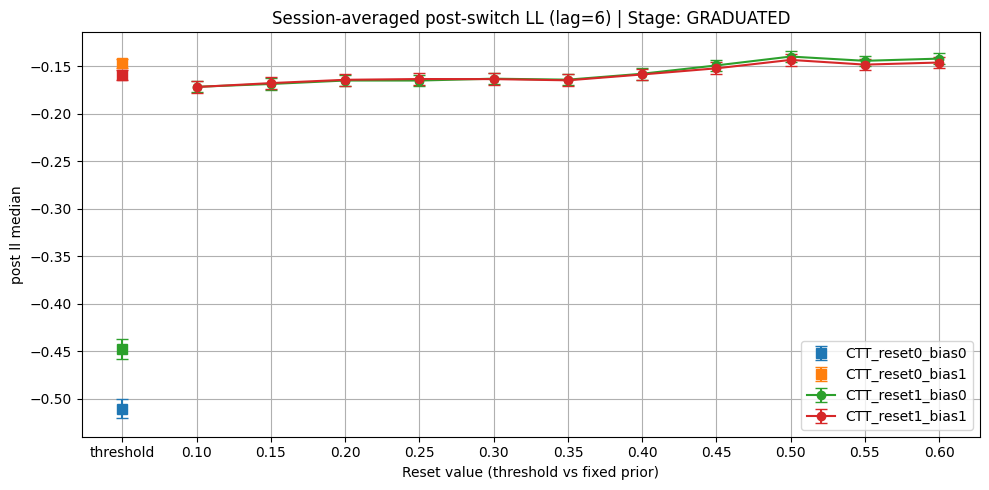

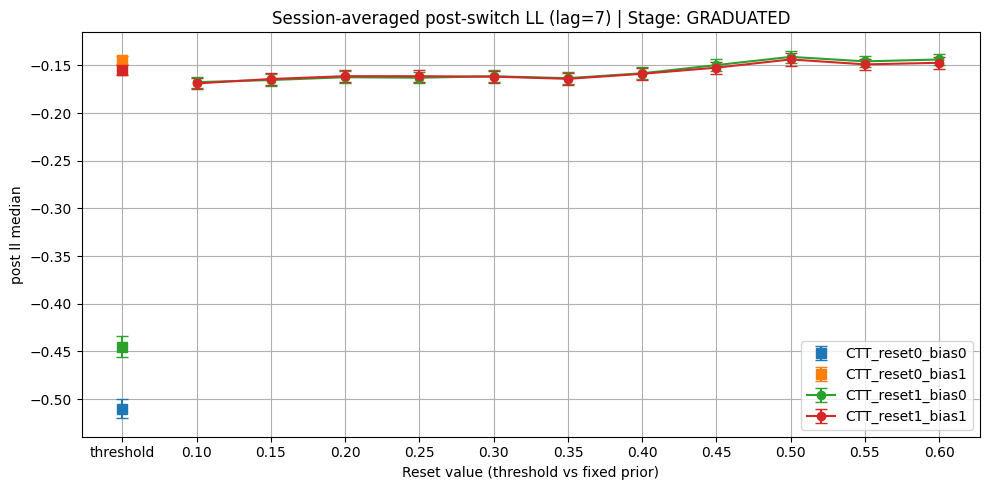

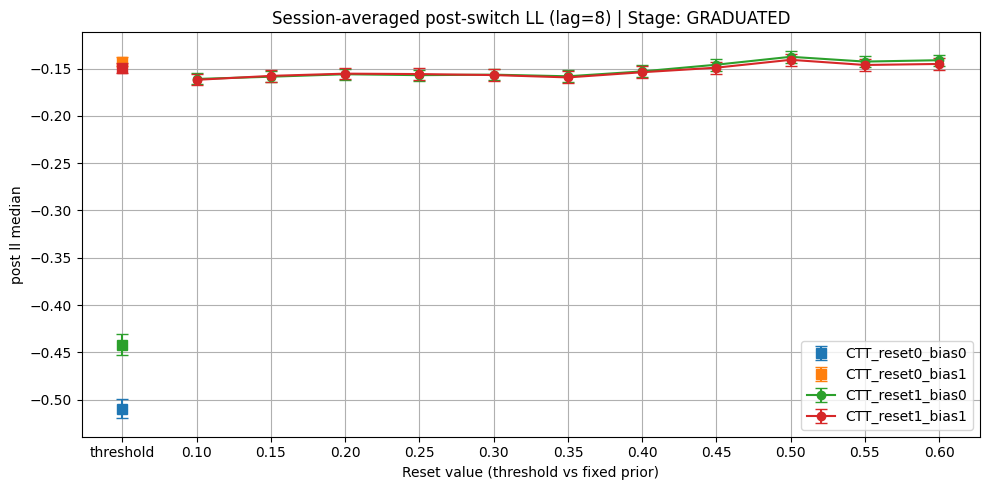

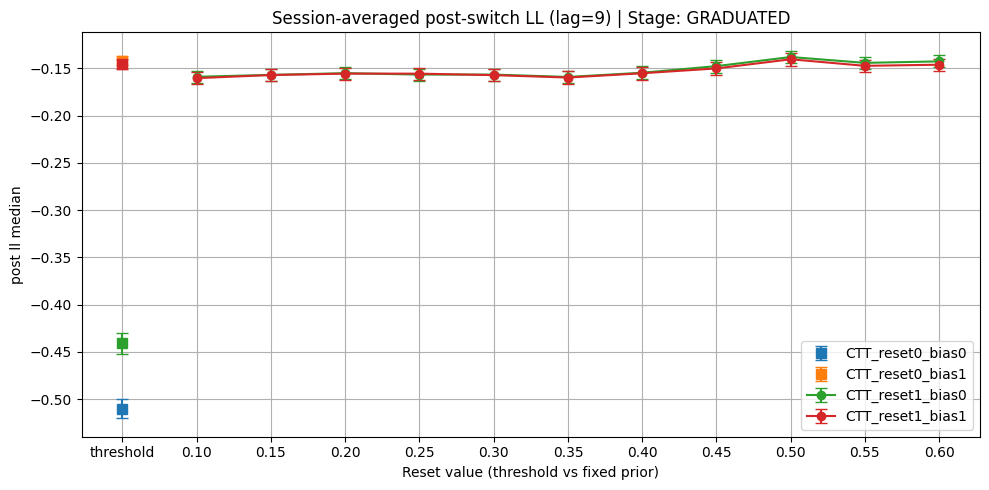

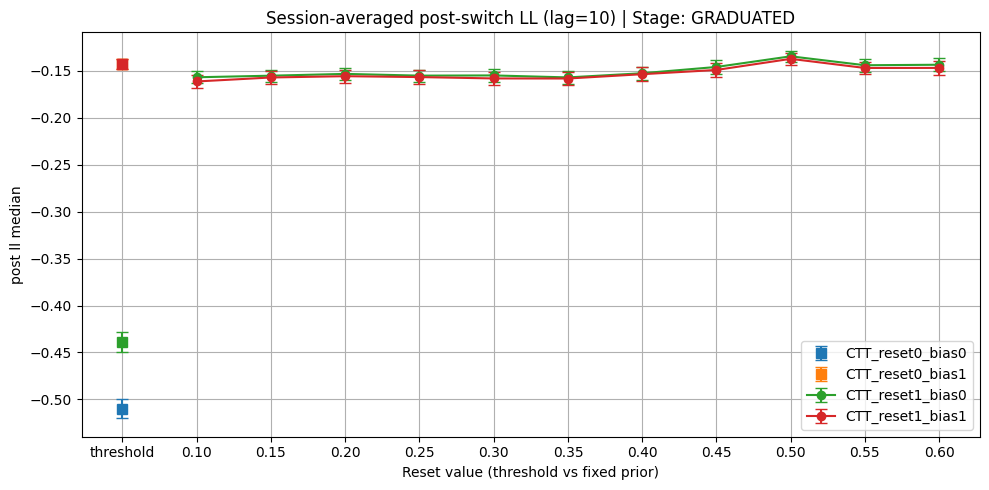

In [44]:
plot_post_switch_ll_by_lag_vs_reset_value(
    combined_df2,
    value_key="post_switch_ll_by_lag_median",
    k_max=10,
    stage_filter="GRADUATED",
    title_prefix="Session-averaged post-switch LL",
)
